# Progress report 1: Microstrip
**Date:** 10-03-2026
**AUTHOR:** Mateo IBARRA GOMEZ

This report summarizes the work done on the HFSS simulations according to Romain's indications in *Simus pour Mateo - 2026-06-03.pptx*.

## Objective
-Through HFSS simulations of a microstrip and a GSG structure determine for which parameters the field fills a larger volume of the substrate. The parameters are the width of the line and the thickness of the substrate.

## Microstrip
Three values for w_line are considered: 30, 50, 200 um.
Four values for h_subs are considered: 50, 100, 200, 500 um.
Input power P_in = 1 mW

For each configuration w_line, h_subs, extract the surface for which Hx > 1 Oe

### Steps
1. The microstrip is visualized in the xz plane for each case to have a better idea of the dimensions
2. The guided wavelength lambda_g and the higher modes cut-off frequency f_c are calculated to choose L and the operation frequency
3. The parameters S11 and S21 are plotted for each case
4. The field Hx is plotted in the yz plane and x=0 to identify where Hx > 1 Oe
5. At the given y coordinate the field Hx is visualized in the xz plane to study the distribution of Hx in the substrate

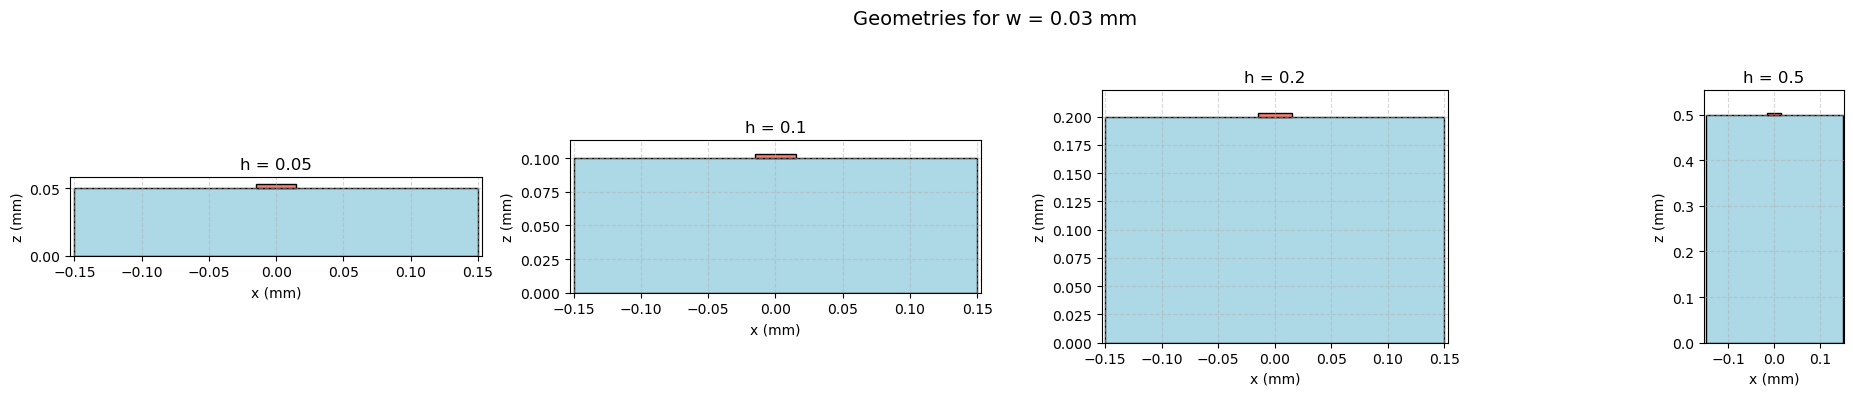

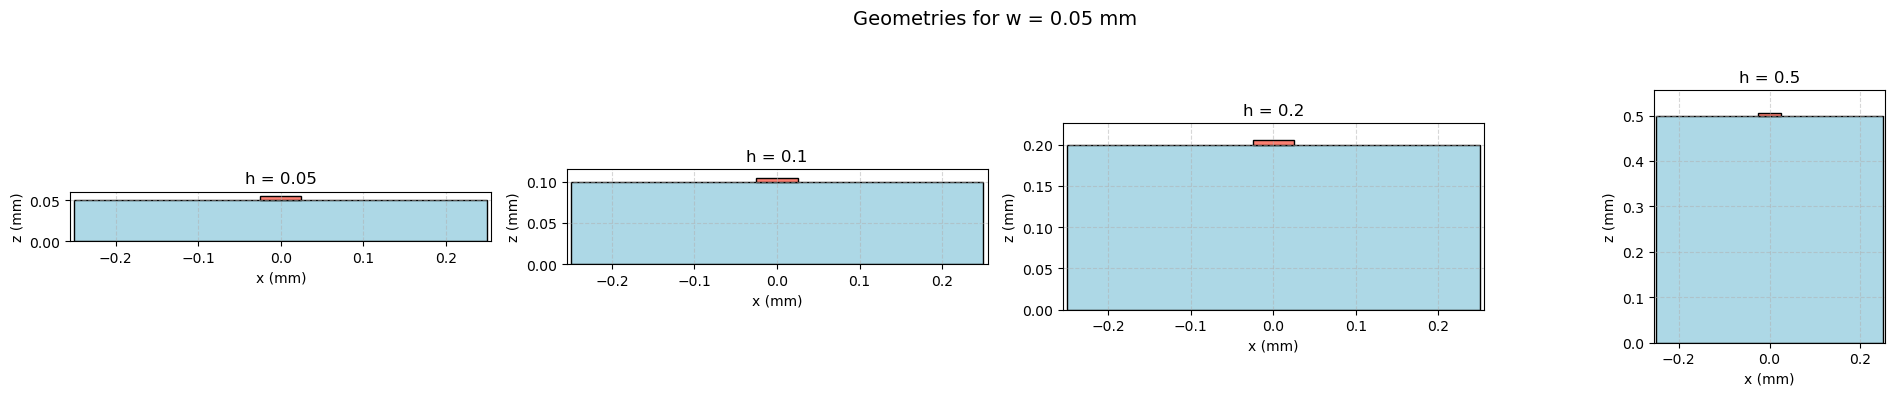

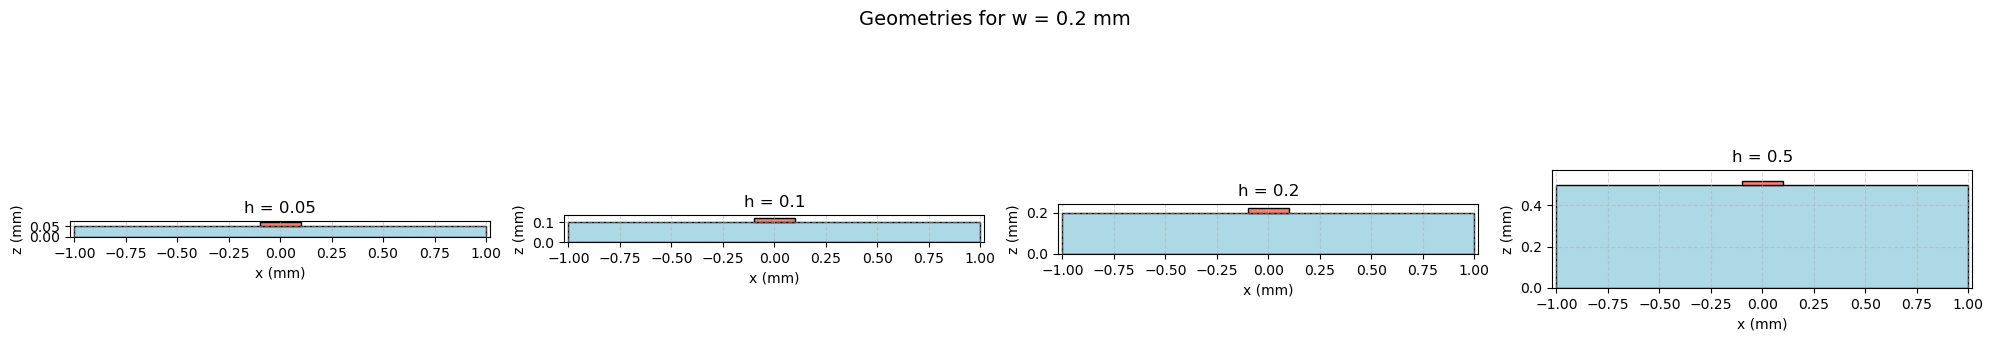

In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


class GeometryCase:
    """Represents one (w, h) geometry configuration."""

    def __init__(self, w: float, h: float):
        self.w = w
        self.h = h

    @property
    def top_width(self) -> float:
        return self.w

    @property
    def top_height(self) -> float:
        return self.w / 10

    @property
    def bottom_width(self) -> float:
        return self.w * 10

    @property
    def bottom_height(self) -> float:
        return self.h

    def draw(self, ax):
        """Draw the stacked rectangles on the given axis."""
        # Bottom rectangle: centered at x = 0, base at y = 0
        bottom_x = -self.bottom_width / 2
        bottom_y = 0

        # Top rectangle: centered at x = 0, exactly on top of bottom rectangle
        top_x = -self.top_width / 2
        top_y = self.bottom_height

        bottom_rect = Rectangle(
            (bottom_x, bottom_y),
            self.bottom_width,
            self.bottom_height,
            facecolor="lightblue",
            edgecolor="black",
            label="Bottom rectangle"
        )

        top_rect = Rectangle(
            (top_x, top_y),
            self.top_width,
            self.top_height,
            facecolor="salmon",
            edgecolor="black",
            label="Top rectangle"
        )

        ax.add_patch(bottom_rect)
        ax.add_patch(top_rect)

        total_height = self.bottom_height + self.top_height
        max_width = max(self.bottom_width, self.top_width)

        ax.set_xlim(-max_width / 2 - 0.1 * self.w, max_width / 2 + 0.1 * self.w)
        ax.set_ylim(0, total_height + 0.1 * total_height)

        ax.set_aspect("equal")
        ax.set_title(f"h = {self.h}")
        ax.set_xlabel("x (mm)")
        ax.set_ylabel("z (mm)")
        ax.grid(True, linestyle="--", alpha=0.5)


class GeometryPlotter:
    """Loads data and creates grouped figures by unique w."""

    def __init__(self, csv_path: str):
        self.csv_path = csv_path
        self.df = None

    def load_data(self):
        """Read the CSV and keep only unique (w, h) pairs."""
        df = pd.read_csv(self.csv_path)

        # Keep only required columns
        df = df[["w [mm]", "h [mm]"]].dropna()

        # Remove duplicate (w, h) pairs
        df = df.drop_duplicates().sort_values(["w [mm]", "h [mm]"]).reset_index(drop=True)

        self.df = df

    def plot_grouped_by_w(self):
        """Create one figure per unique w value."""
        if self.df is None:
            raise ValueError("Data not loaded. Call load_data() first.")

        unique_w_values = sorted(self.df["w [mm]"].unique())

        for w_value in unique_w_values:
            group = self.df[self.df["w [mm]"] == w_value].sort_values("h [mm]")
            n = len(group)

            ncols = min(4, n)
            nrows = math.ceil(n / ncols)

            fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))

            # Make axes always iterable
            if n == 1:
                axes = [axes]
            else:
                axes = axes.flatten()

            fig.suptitle(f"Geometries for w = {w_value} mm", fontsize=14)

            for ax, (_, row) in zip(axes, group.iterrows()):
                case = GeometryCase(w=row["w [mm]"], h=row["h [mm]"])
                case.draw(ax)

            # Hide unused axes
            for ax in axes[len(group):]:
                ax.axis("off")

            plt.tight_layout(rect=[0, 0, 1, 0.95])
            plt.show()


if __name__ == "__main__":
    plotter = GeometryPlotter("Project3_param_sweep_ReZo_ImZo_S.csv")
    plotter.load_data()
    plotter.plot_grouped_by_w()

The following table shows for each couple w_line, h_subs, the corresponding effective permitivity, the cutoff frequency f_c of the first higher-order surface wave mode and the guided wavelength, in order to better choose the length L of the line and the frequency f_ext of the applied field in the simulations.

In [3]:
import numpy as np
import pandas as pd

def effective_permittivity(eps_r, h_subs, w_line):
    return (eps_r + 1) / 2 + (eps_r - 1) / 2 * (1 / np.sqrt(1 + 12 * h_subs / w_line))

# Constants
c = 3e8
eps_r = 12
f = 9.4e9  # Hz

h_subs = np.array((0.050, 0.100, 0.200, 0.500)) * 1e-3
w_line = np.array((0.030, 0.050, 0.200)) * 1e-3

rows = []

for h in h_subs:
    # f_c depends only on h_subs
    f_c = c / (4 * h * np.sqrt(eps_r - 1))
    
    for w in w_line:
        eps_eff = effective_permittivity(eps_r, h, w)
        lambda_g = c / f / np.sqrt(eps_eff)
        
        rows.append({
            "h_subs (mm)": h * 1e3,
            "w_line (mm)": w * 1e3,
            "eps_eff": eps_eff,
            "f_c (GHz)": f_c * 1e-9,
            "lambda_g (mm)": lambda_g * 1e3,
        })

df = pd.DataFrame(rows)

# Optional: prettier formatting for terminal display
df = df.round({
    "h_subs (mm)": 3,
    "w_line (mm)": 3,
    "eps_eff": 3,
    "f_c (GHz)": 3,
    "lambda_g (mm)": 3
})

print(df.to_string(index=False))

 h_subs (mm)  w_line (mm)  eps_eff  f_c (GHz)  lambda_g (mm)
        0.05         0.03    7.700    452.267         11.501
        0.05         0.05    8.025    452.267         11.266
        0.05         0.20    9.250    452.267         10.494
        0.10         0.03    7.359    226.134         11.765
        0.10         0.05    7.600    226.134         11.577
        0.10         0.20    8.579    226.134         10.896
        0.20         0.03    7.111    113.067         11.968
        0.20         0.05    7.286    113.067         11.824
        0.20         0.20    8.025    113.067         11.266
        0.50         0.03    6.888     45.227         12.160
        0.50         0.05    7.000     45.227         12.063
        0.50         0.20    7.488     45.227         11.663


Therefore, L << 10 mm, and f_ext << 45 GHz

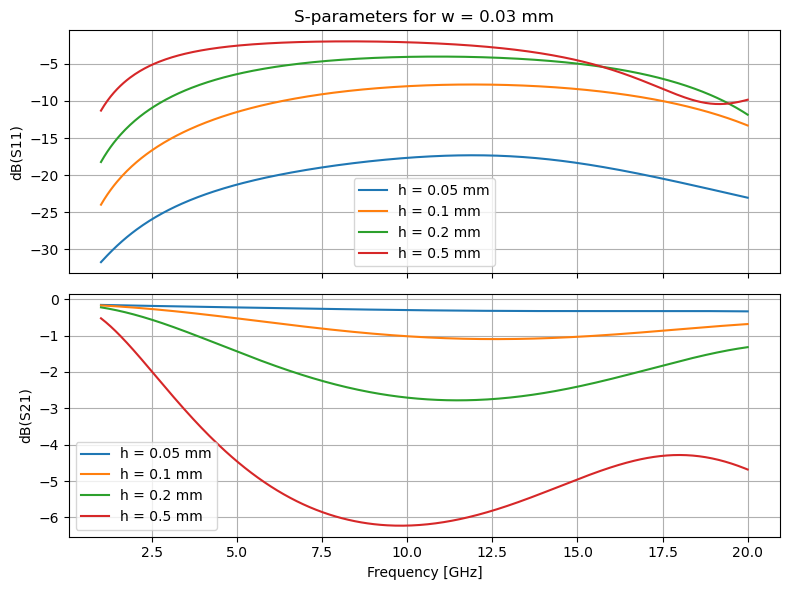

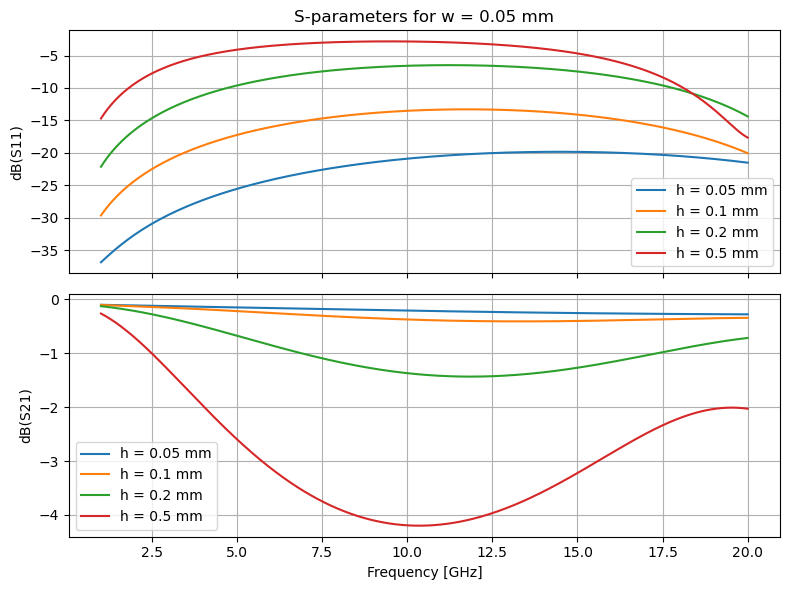

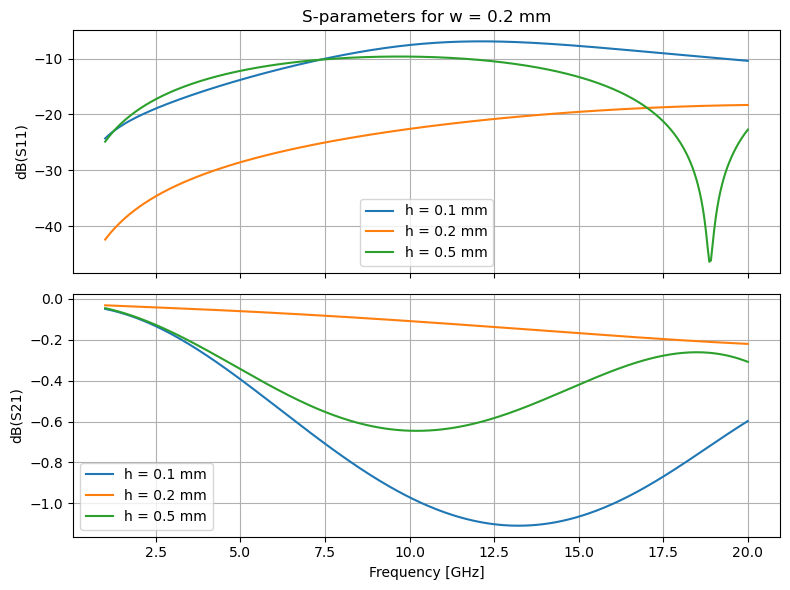

In [5]:
import matplotlib.pyplot as plt


class HFSSPlotter:
    def __init__(self, csv_file):
        self.csv_file = csv_file
        self.data = None

        self.col_h = "h [mm]"
        self.col_w = "w [mm]"
        self.col_freq = "Freq [GHz]"
        self.col_s11 = "dB(S(1,1)) []"
        self.col_s21 = "dB(S(2,1)) []"

    def load_data(self):
        self.data = pd.read_csv(self.csv_file)

    def check_columns(self):
        required_columns = [
            self.col_h,
            self.col_w,
            self.col_freq,
            self.col_s11,
            self.col_s21,
        ]

        missing = [col for col in required_columns if col not in self.data.columns]
        if missing:
            raise ValueError(f"Missing columns: {missing}")

    def plot_for_each_w(self):
        unique_w_values = sorted(self.data[self.col_w].unique())

        for w_value in unique_w_values:
            df_w = self.data[self.data[self.col_w] == w_value].copy()

            fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

            for h_value in sorted(df_w[self.col_h].unique()):
                df_wh = df_w[df_w[self.col_h] == h_value].copy()
                df_wh = df_wh.sort_values(by=self.col_freq)

                axes[0].plot(
                    df_wh[self.col_freq],
                    df_wh[self.col_s11],
                    label=f"h = {h_value} mm"
                )

                axes[1].plot(
                    df_wh[self.col_freq],
                    df_wh[self.col_s21],
                    label=f"h = {h_value} mm"
                )

            axes[0].set_ylabel("dB(S11)")
            axes[0].set_title(f"S-parameters for w = {w_value} mm")
            axes[0].grid(True)
            axes[0].legend()

            axes[1].set_xlabel("Frequency [GHz]")
            axes[1].set_ylabel("dB(S21)")
            axes[1].grid(True)
            axes[1].legend()

            plt.tight_layout()
            plt.show()

    def run(self):
        self.load_data()
        self.check_columns()
        self.plot_for_each_w()


if __name__ == "__main__":
    csv_file = "Project2_S_Parameter_Plots.csv"
    plotter = HFSSPlotter(csv_file)
    plotter.run()

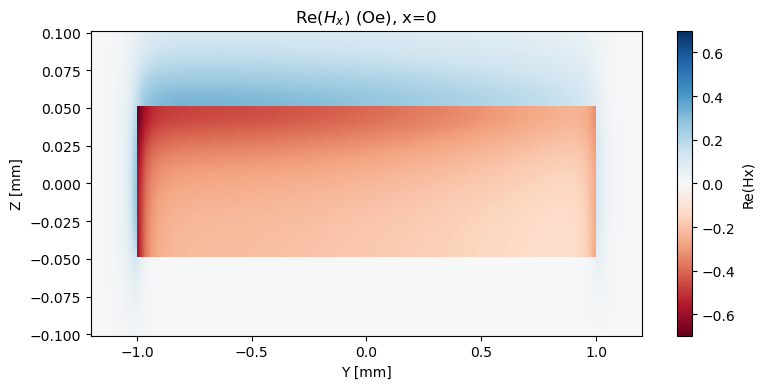

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

class HxMapPlotter:
    def __init__(self, filename):
        self.filename = filename

    def load_data(self):
        """
        Load numeric data from the file.
        Assumes:
          - line 1: metadata
          - line 2: column names
          - line 3 onward: numeric data
        """
        return np.loadtxt(self.filename, skiprows=2)

    def build_grid(self, data):
        y = data[:, 1]
        z = data[:, 2]
        hx_real = data[:, 3]

        y_unique = np.unique(y)
        z_unique = np.unique(z)

        grid = np.full((len(z_unique), len(y_unique)), np.nan)

        y_index = {val: i for i, val in enumerate(y_unique)}
        z_index = {val: i for i, val in enumerate(z_unique)}

        for yi, zi, hi in zip(y, z, hx_real):
            grid[z_index[zi], y_index[yi]] = hi*4*np.pi/1000*np.sqrt(1e-3)

        return y_unique, z_unique, grid

    def plot(self):
        """
        Plot the real part of Hx as a 2D color map.
        """
        data = self.load_data()
        y_unique, z_unique, grid = self.build_grid(data)
        vmax = np.nanmax(np.abs(grid))
        norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
        
        plt.figure(figsize=(8, 4))
        plt.pcolormesh(y_unique*1e3, z_unique*1e3, grid, shading="auto",cmap="RdBu",norm=norm)
        plt.colorbar(label="Re(Hx)")
        plt.xlabel("Y [mm]")
        plt.ylabel("Z [mm]")
        plt.title('Re($H_x$) (Oe), x=0')
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    plotter = HxMapPlotter("h_x_data3.txt")
    plotter.plot()

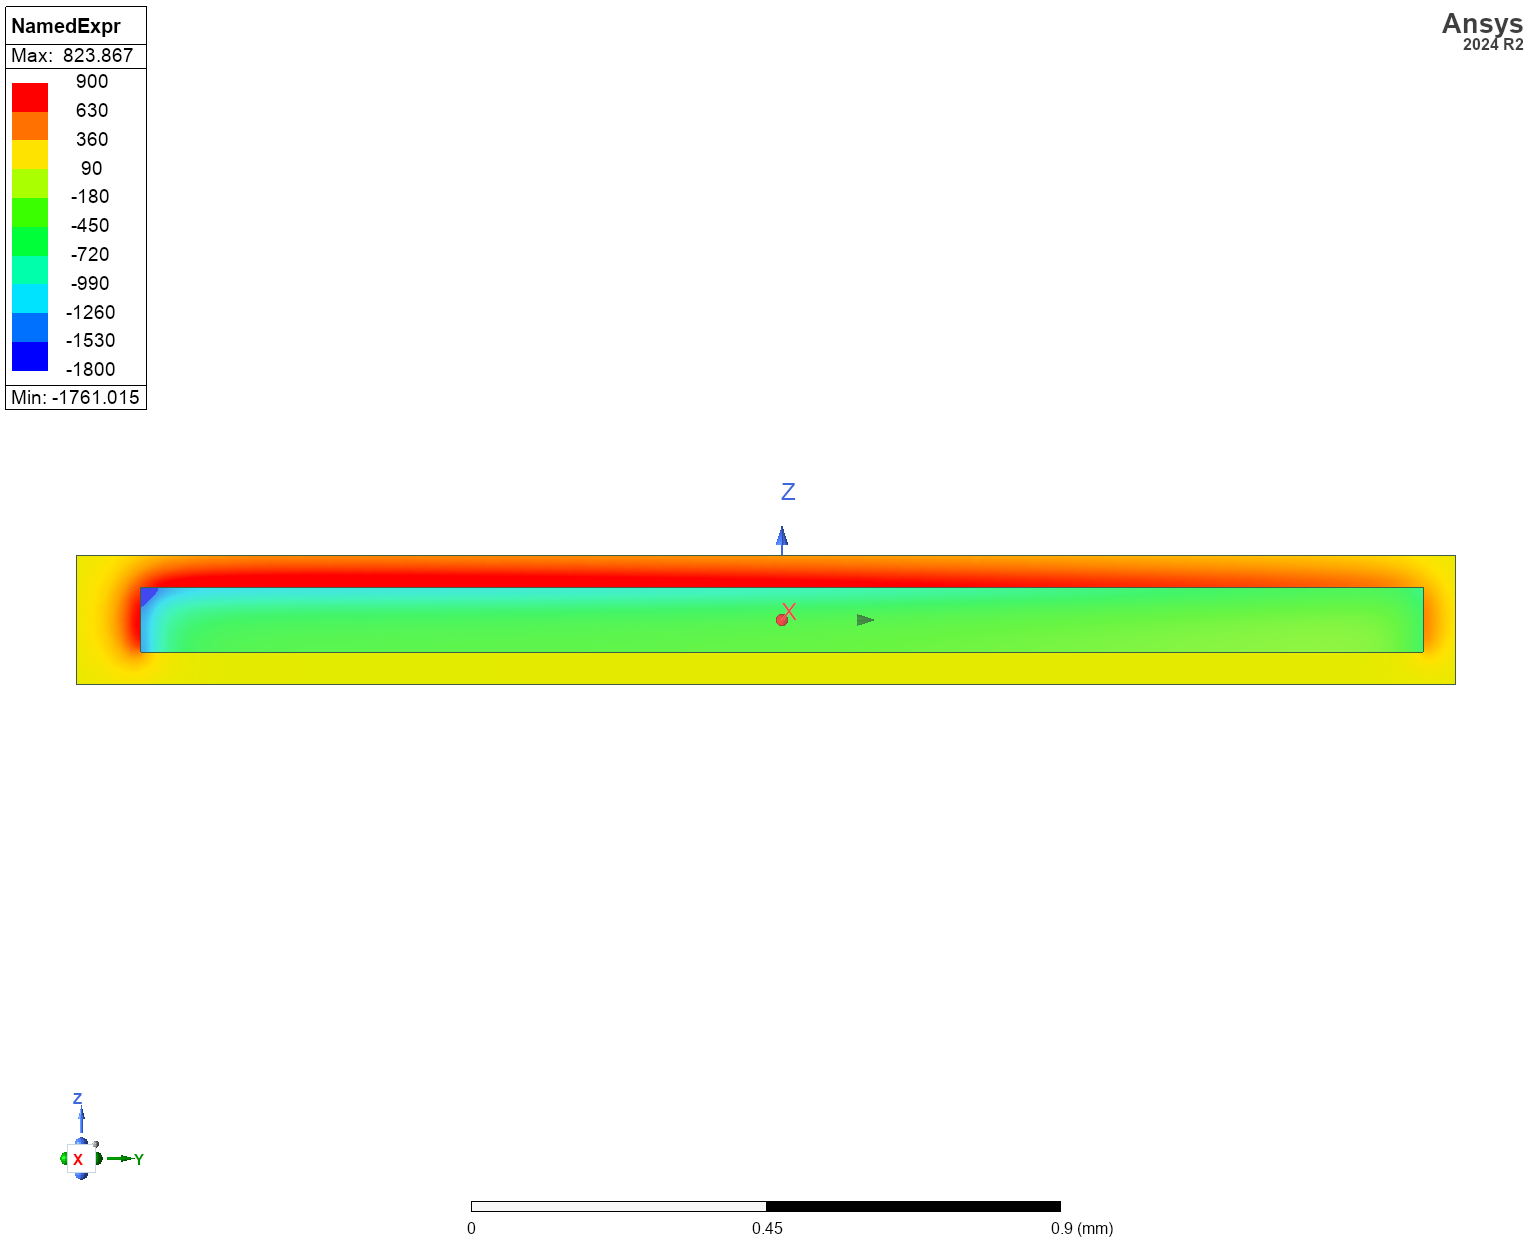

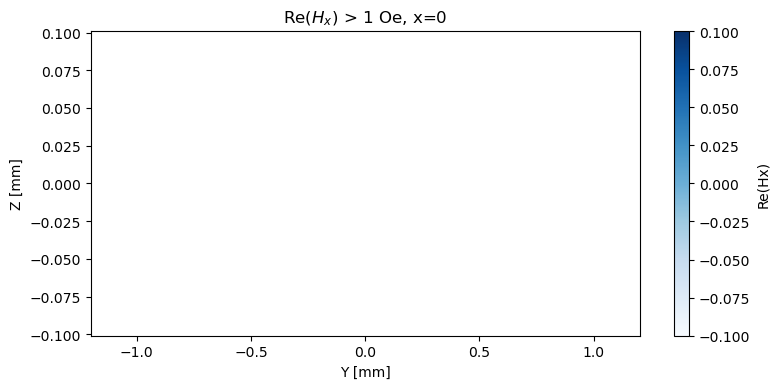

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

class HxMapPlotter:
    def __init__(self, filename):
        self.filename = filename

    def load_data(self):
        """
        Load numeric data from the file.
        Assumes:
          - line 1: metadata
          - line 2: column names
          - line 3 onward: numeric data
        """
        return np.loadtxt(self.filename, skiprows=2)

    def build_grid(self, data):
        y = data[:, 1]
        z = data[:, 2]
        hx_real = data[:, 3]

        y_unique = np.unique(y)
        z_unique = np.unique(z)

        grid = np.full((len(z_unique), len(y_unique)), np.nan)

        y_index = {val: i for i, val in enumerate(y_unique)}
        z_index = {val: i for i, val in enumerate(z_unique)}

        for yi, zi, hi in zip(y, z, hx_real):
            grid[z_index[zi], y_index[yi]] = np.abs(hi)*4*np.pi/1000*np.sqrt(1e-3)

        return y_unique, z_unique, grid

    def plot(self):
        """
        Plot the real part of Hx as a 2D color map.
        """
        data = self.load_data()
        y_unique, z_unique, grid = self.build_grid(data)
        #vmax = np.nanmax(np.abs(grid))
        #norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
        
        plt.figure(figsize=(8, 4))
        grid[grid<1]=np.nan
        plt.pcolormesh(y_unique*1e3, z_unique*1e3, grid, shading="auto",cmap="Blues")
        plt.colorbar(label="Re(Hx)")
        plt.xlabel("Y [mm]")
        plt.ylabel("Z [mm]")
        plt.title('Re($H_x$) > 1 Oe, x=0')
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    plotter = HxMapPlotter("h_x_data3.txt")
    plotter.plot()

## Conclusions
- Nowhere the field is larger than 1 Oe (see last figure).
- In these simulations I did not consider the impedance mismatch between the port and the transmission line. Thus, to have S parameters and field plots that reflect better the effect of changing w_line and h_subs I need to remove the effect of reflections
- I forced the max mesh element length to w_line/10 on the surface of the line. I have to verify that my simulations converged and that I obtain the same when I do not impose a  maximum value.


## Finding Zo using wave ports
To verify how much reflection there is in the simulations previously performed, we need to evaluate Zo of the microstrip structure.
Previously I enforced a limit in the mesh size for the line surface as w/10. But following the last meeting I removed this.
1. Launch a simulation to find the right amount of passes and mesh adaptation percentage (w=0.05mm, h=0.05mm)

Convergence was not achieved with: 
- 4 min and 10 max passes, min S error 0.01, mesh percentage 30 % 
- 4 min and 10 max passes, min S error 0.01, mesh percentage 20 %

Convergence was achieved with:
- 4 min and 15 max passes, min S error 0.01, mesh percentage 30 % ---> but the minimum mesh edge length in the line was 29 um, which is too close to w
- 4 min and 15 max passes, min S error 0.01, mesh percentage 30 %, lambda target 0.1 (default is 0.33) ---> minimum mesh edge length in the line was 58 um
- 4 min and 15 max passes, min S error 0.01, mesh percentage 20 %, lambda target 0.1 ---> minimum mesh edge length in the line was 58 um
- same but L reduced to 1mm ---> minimum mesh edge length in the line was 53 um

I will compare the S parameters and Zo obtained when enforcing a maximum size for the mesh with the values obtained with no enforcing to see if the difference is important

### S parameters
- Forcing the length of mesh element to w/10 on the surface of the line
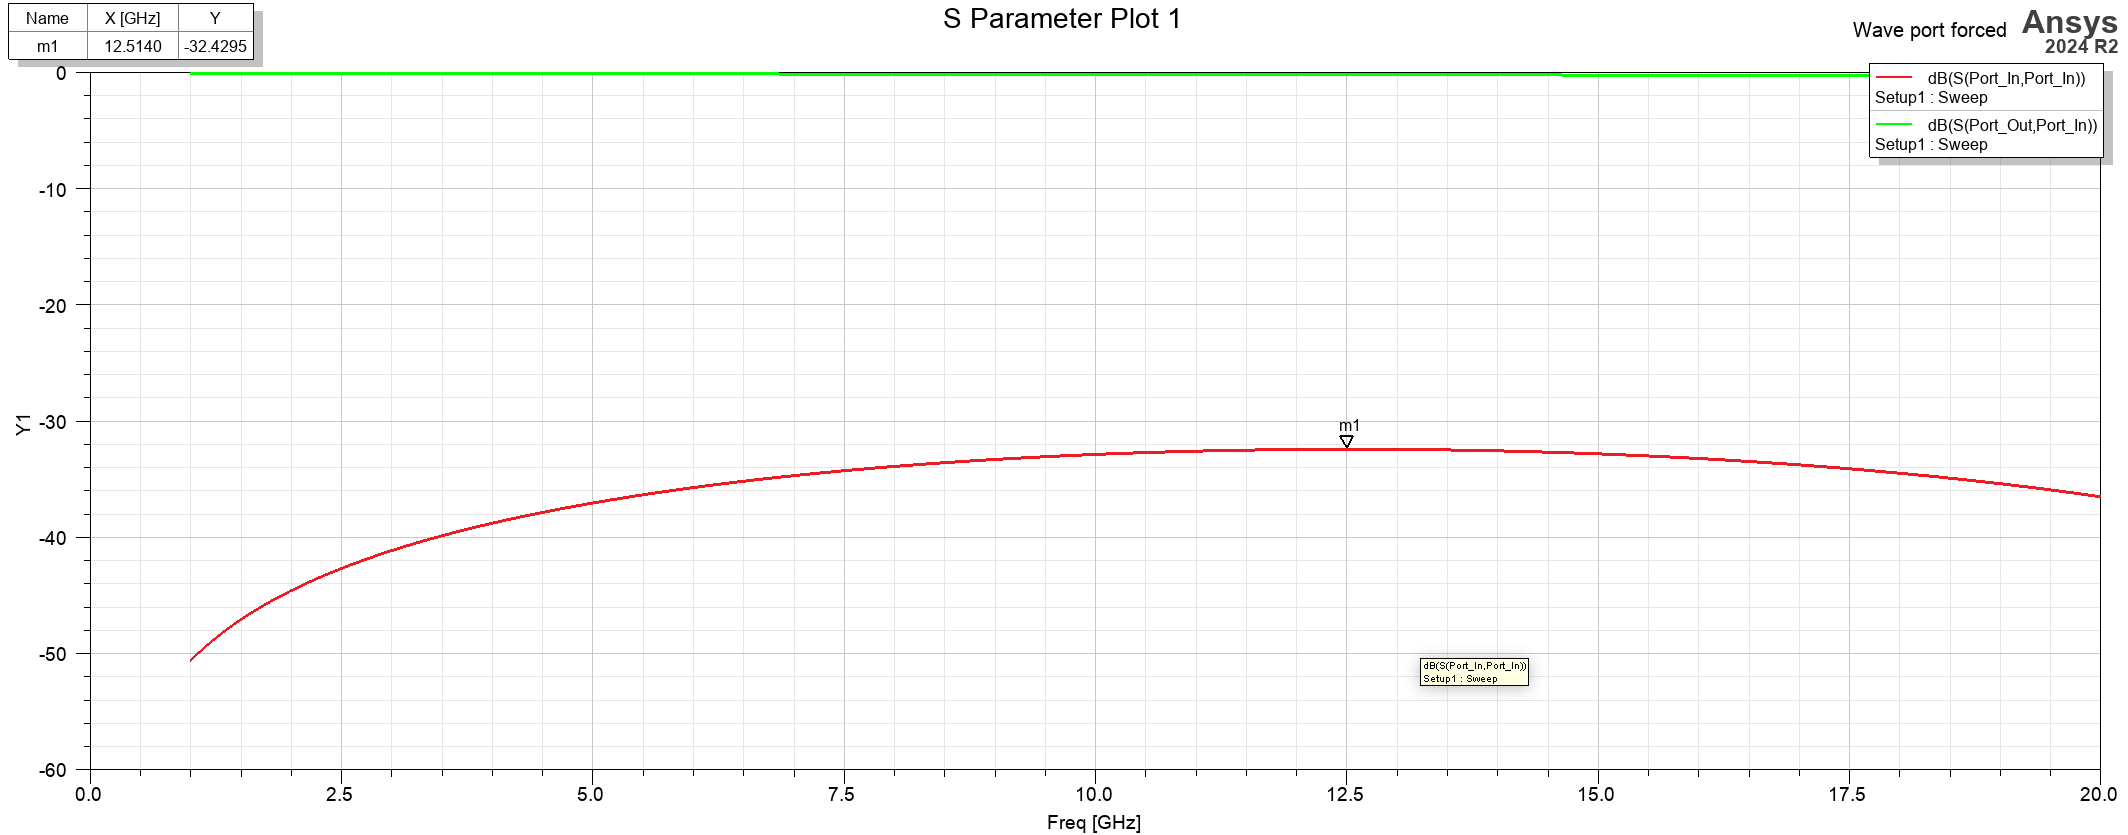

- Not forcing any max length
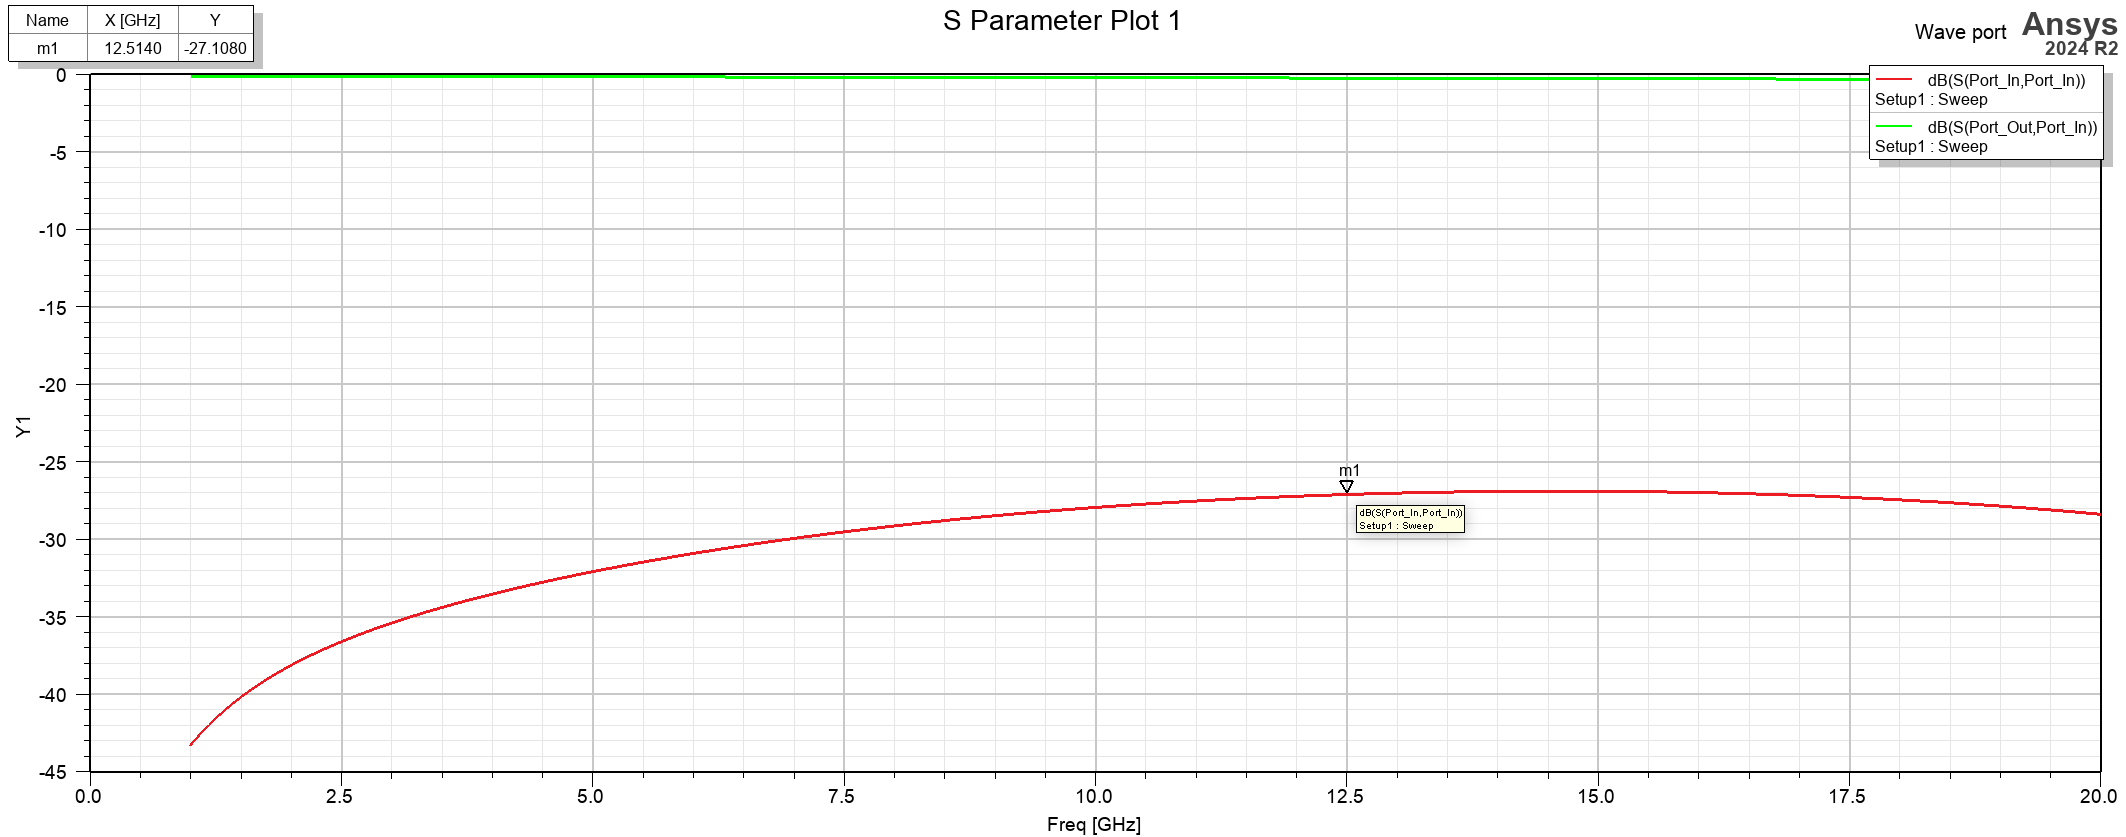

There is a difference of 5 dB between the results

### Mag(Zo)
- Forcing the length of mesh element to w/10 on the surface of the line
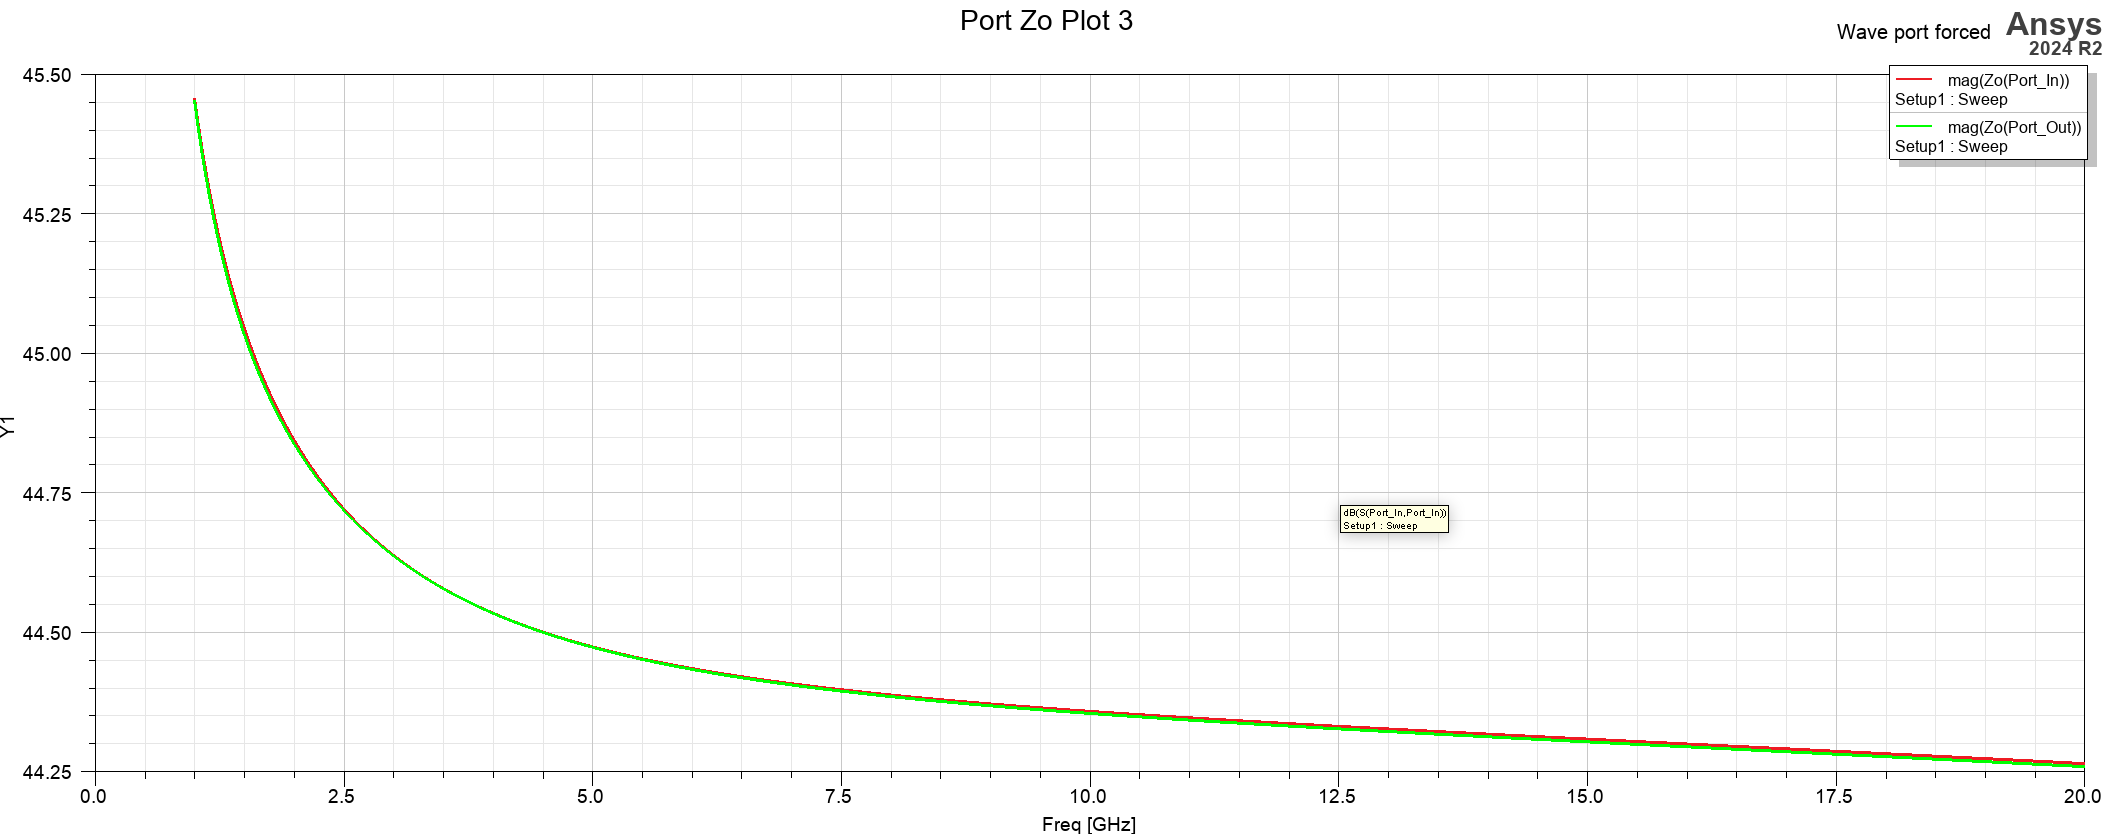

- Not forcing any max length
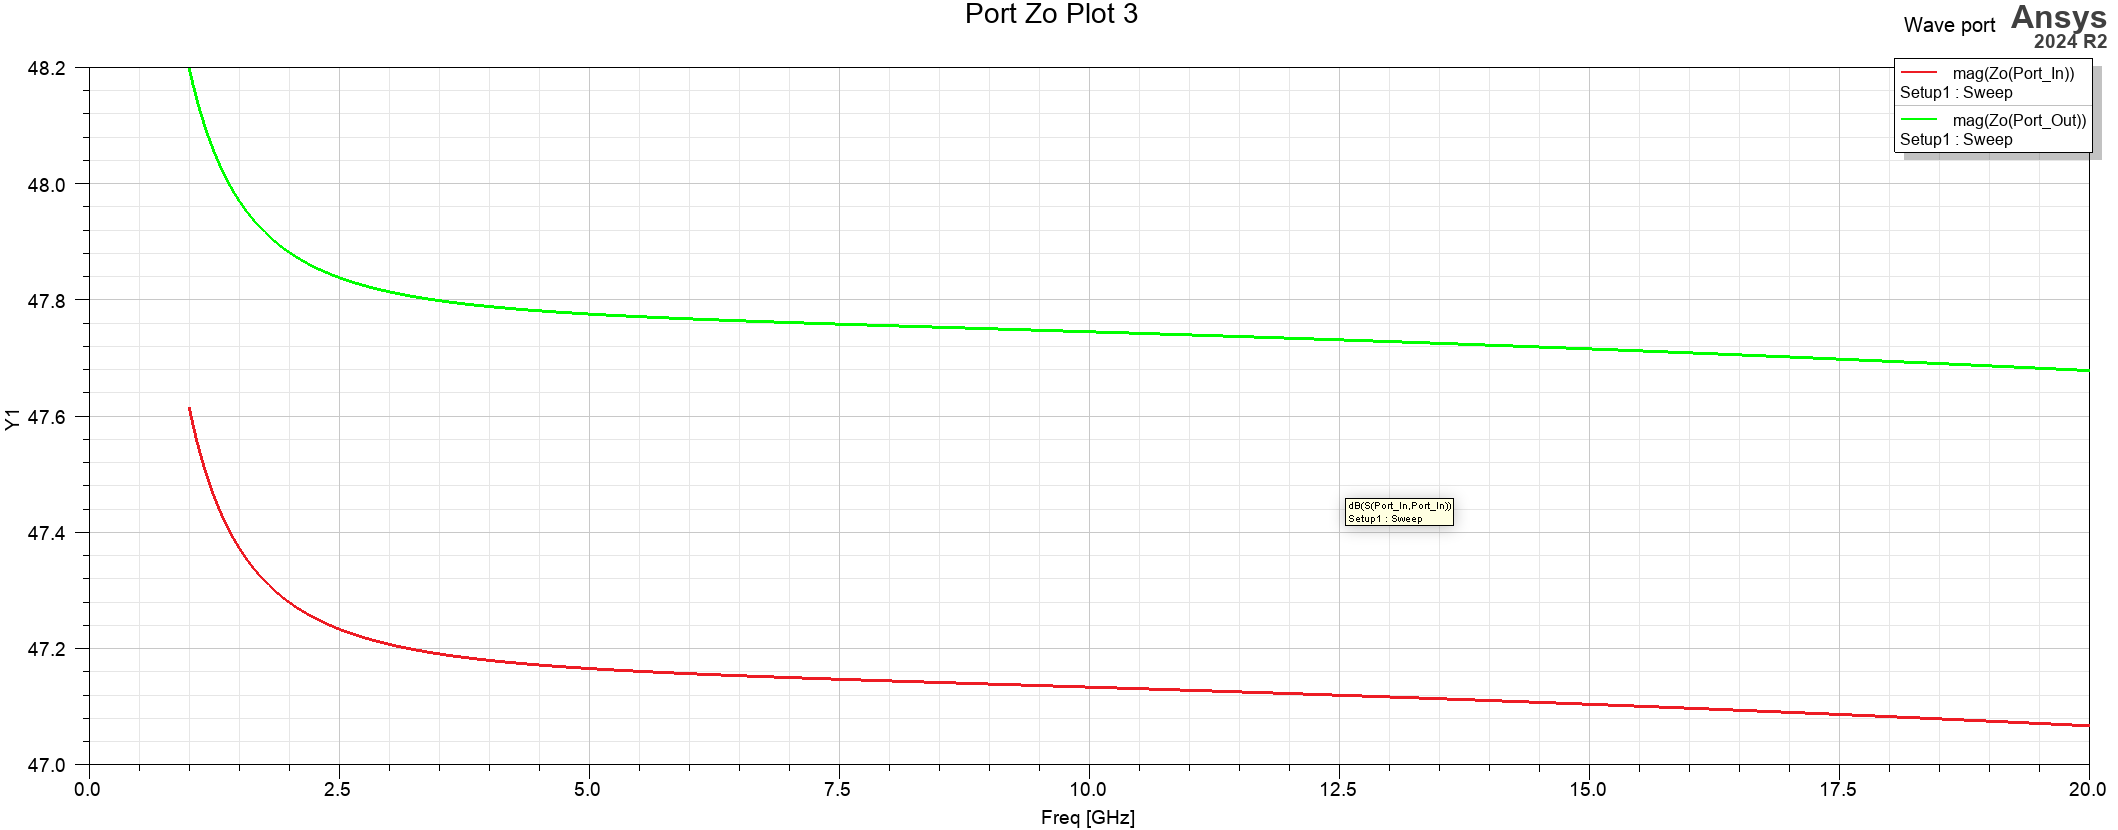


Zo for the two ports converge when the mesh element size is enforced. There is a difference of around 3 Ohms between the two plots shown here.

## Field profile yz plane
- Forcing the length of mesh element to w/10 on the surface of the line
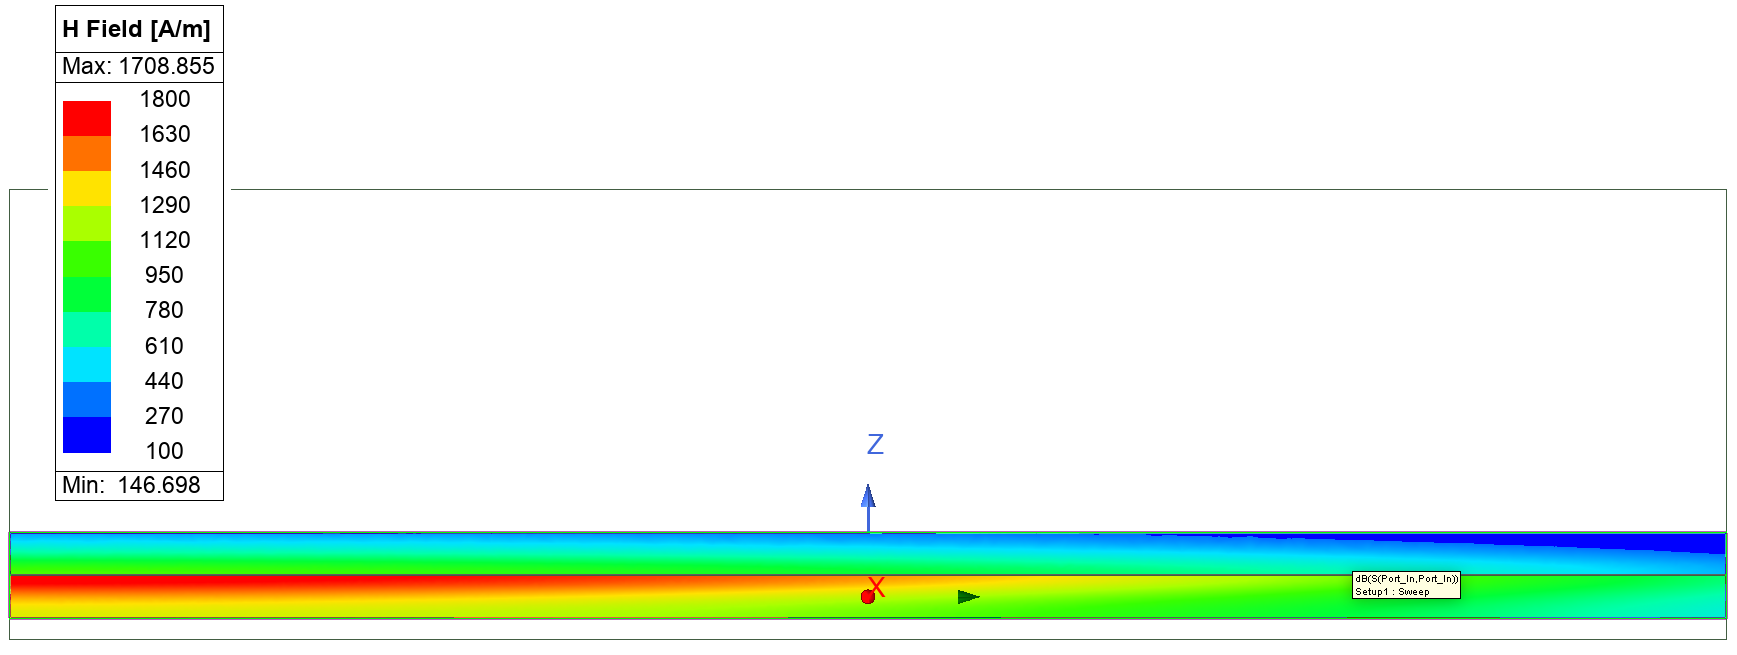
- Not forcing any max length
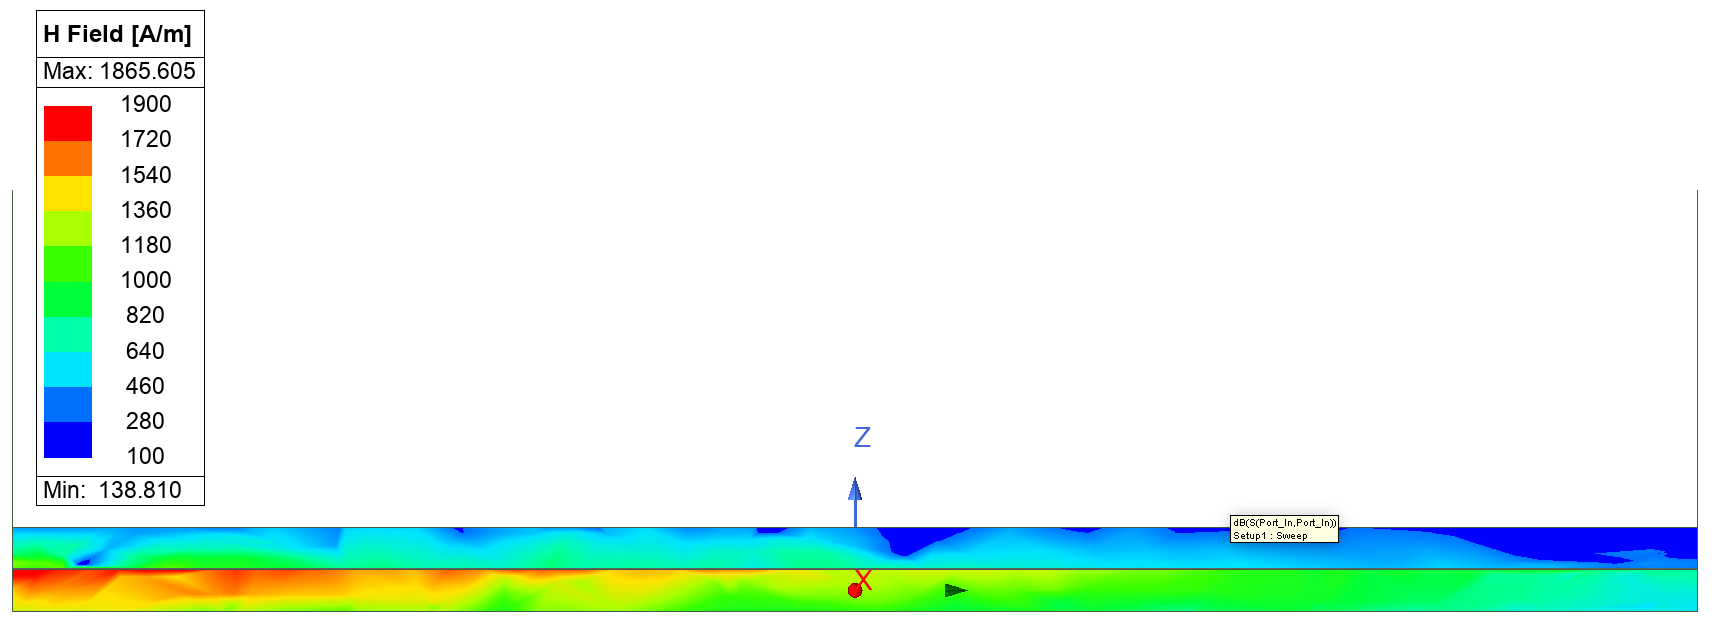

## Field profile xz plane
- Forcing the length of mesh element to w/10 on the surface of the line
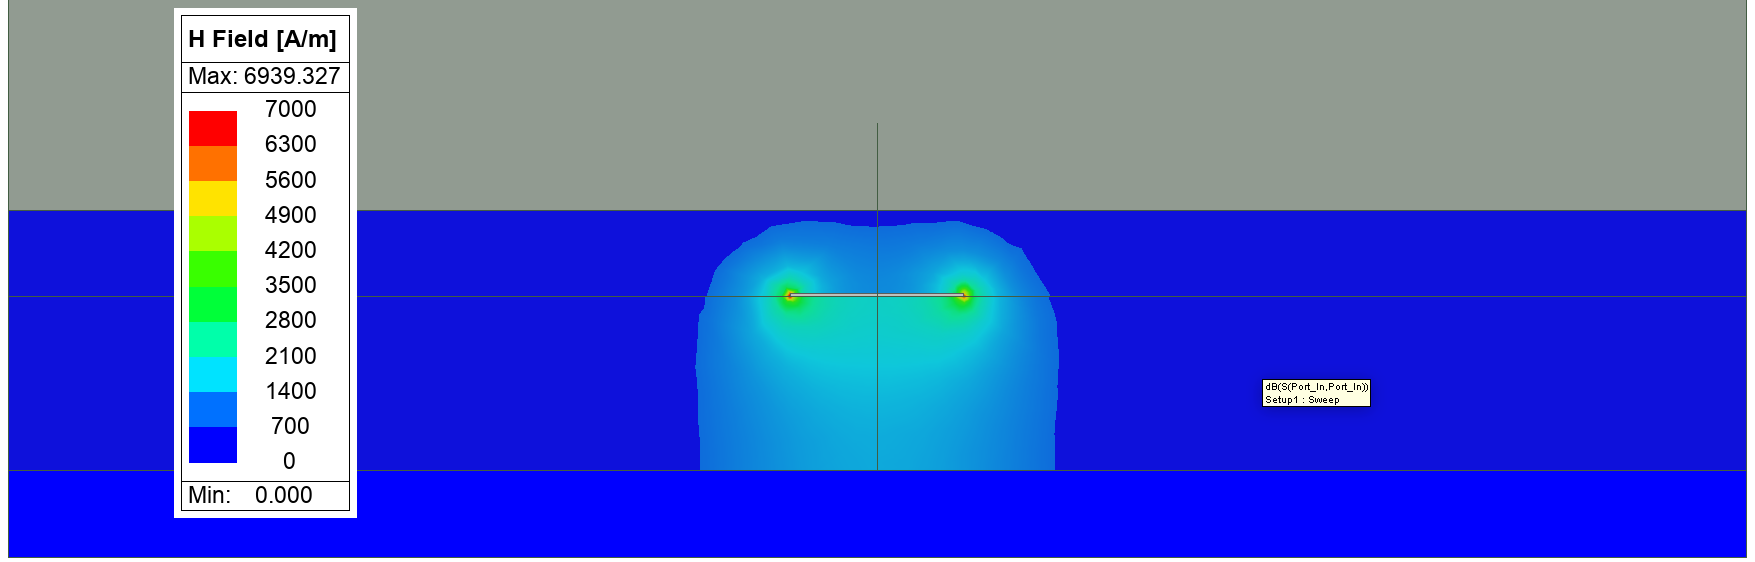
- Not forcing any max length
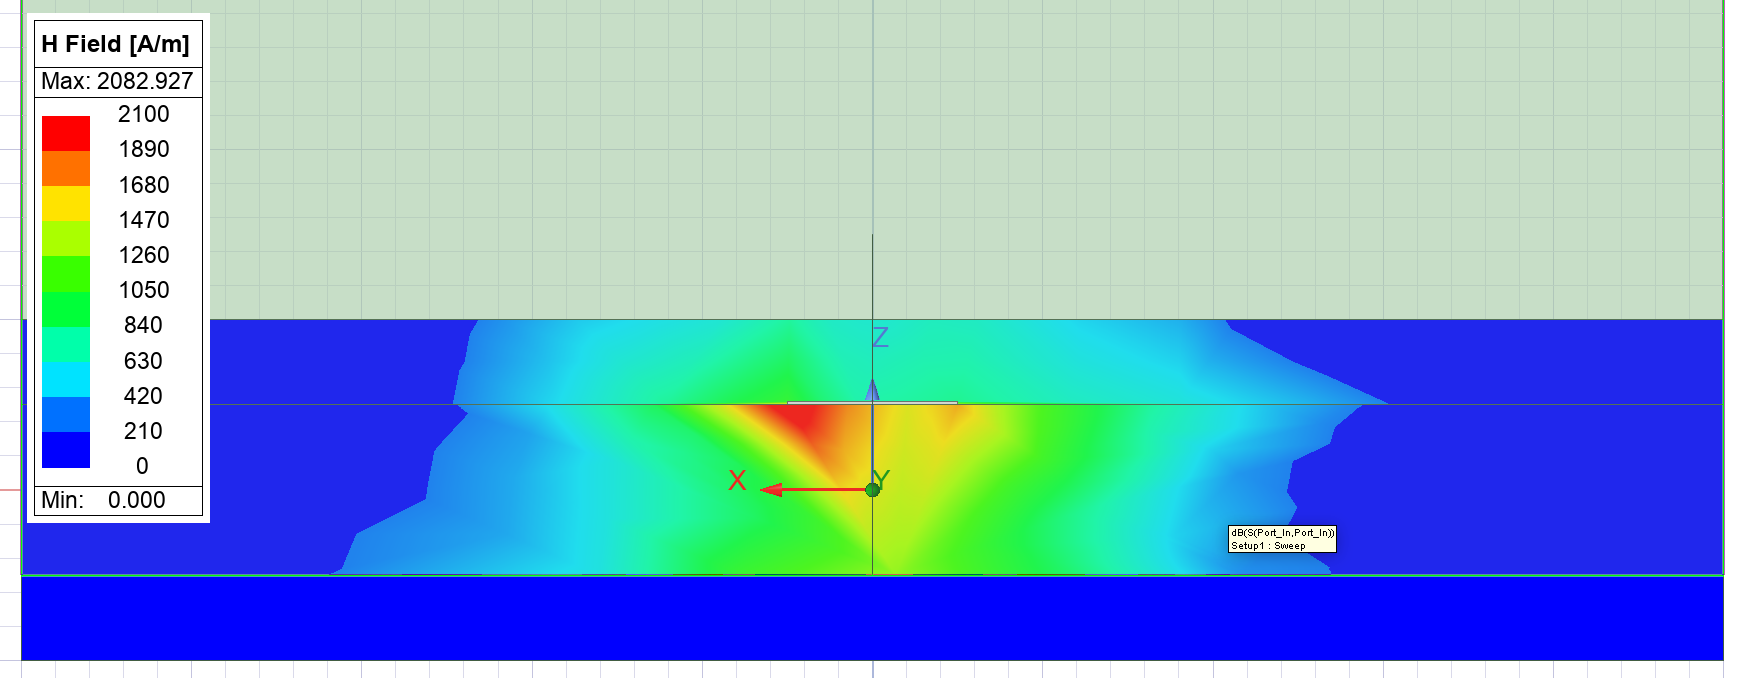

Considering that the field fluctuates much more in the not-forced simulations than in the forced ones, I choose the forced ones to perform the subsequent analysis.

But I will make the restriction on the mesh element size < w/5 instead of < w/10. Here I plot the field in the xz plane to verify:
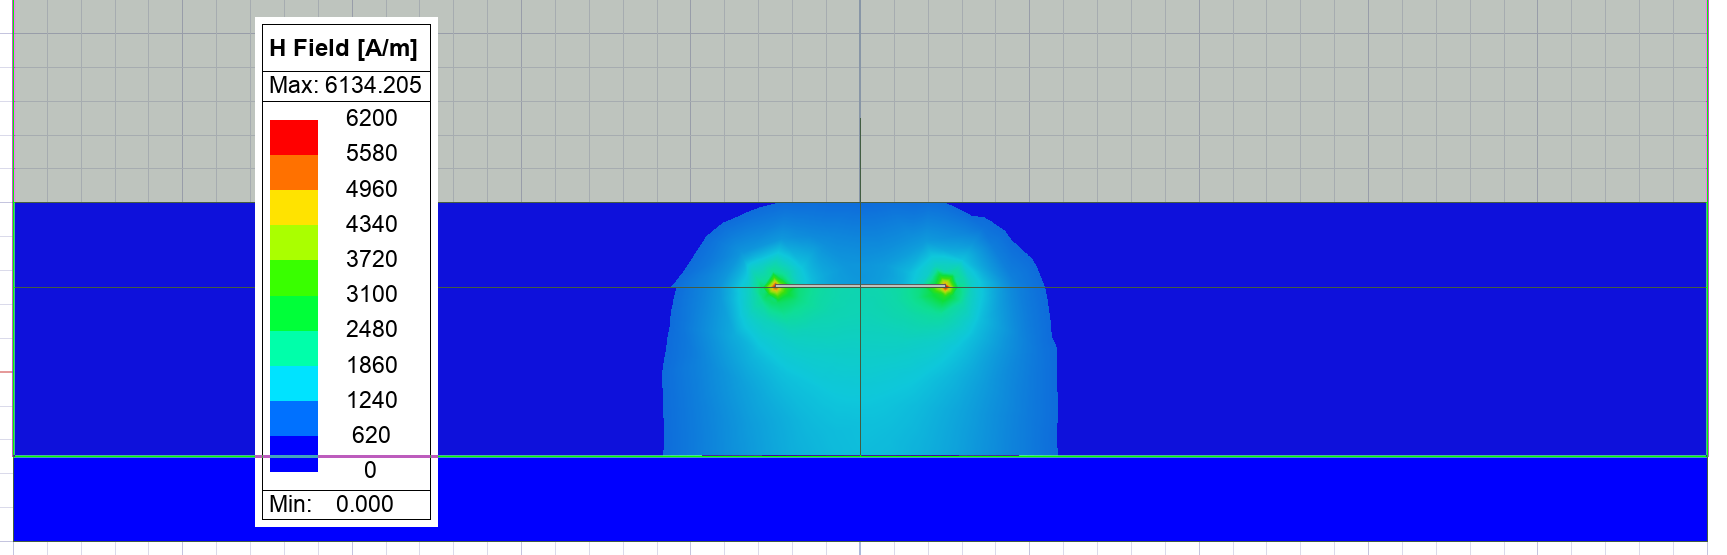

I'll verify that removing that additional volume below the ground plane does not change the results:
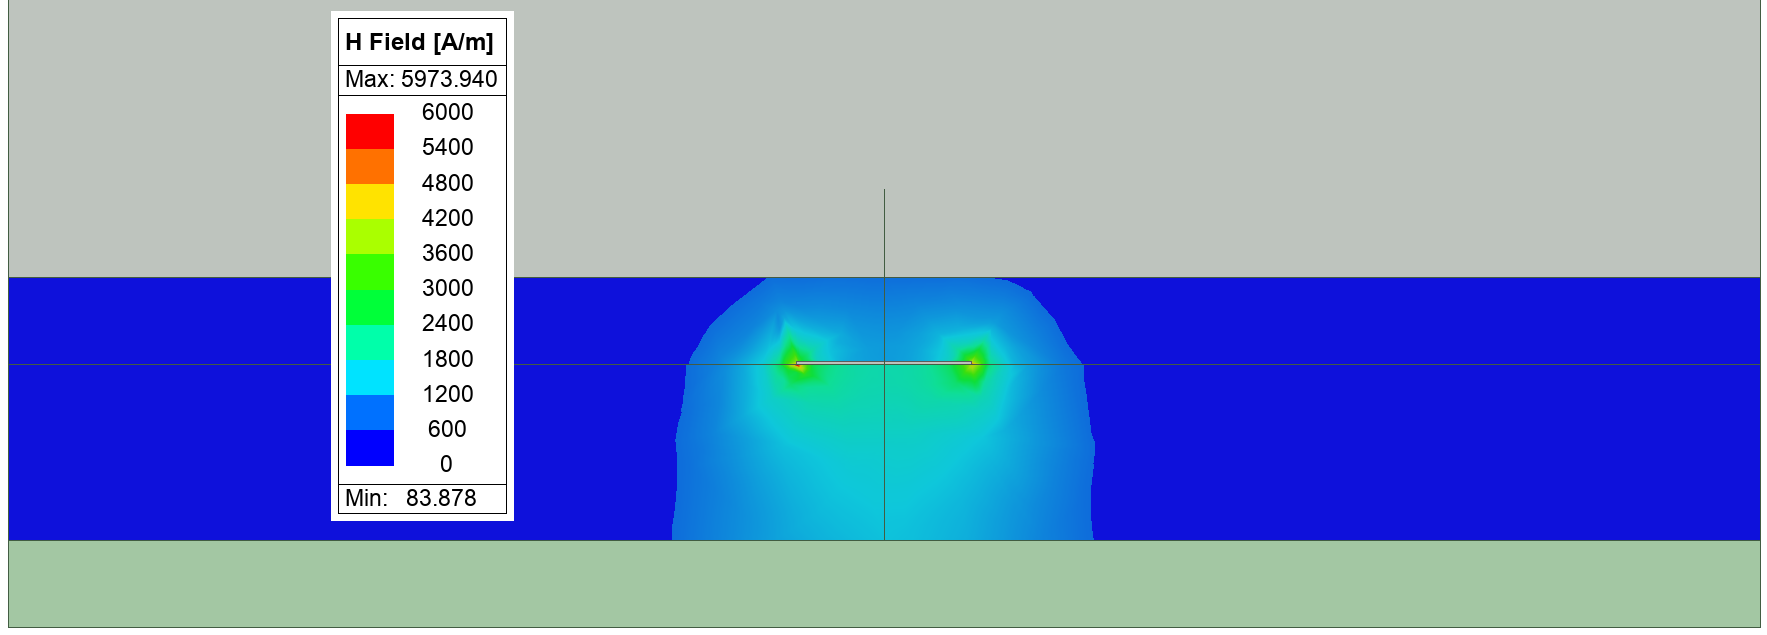

## Extraction of Zo
Here I extract zo at f_ext=9.4 GHz for each case w_line, h_subs from the HFSS simulations where I verified convergence and mesh size.

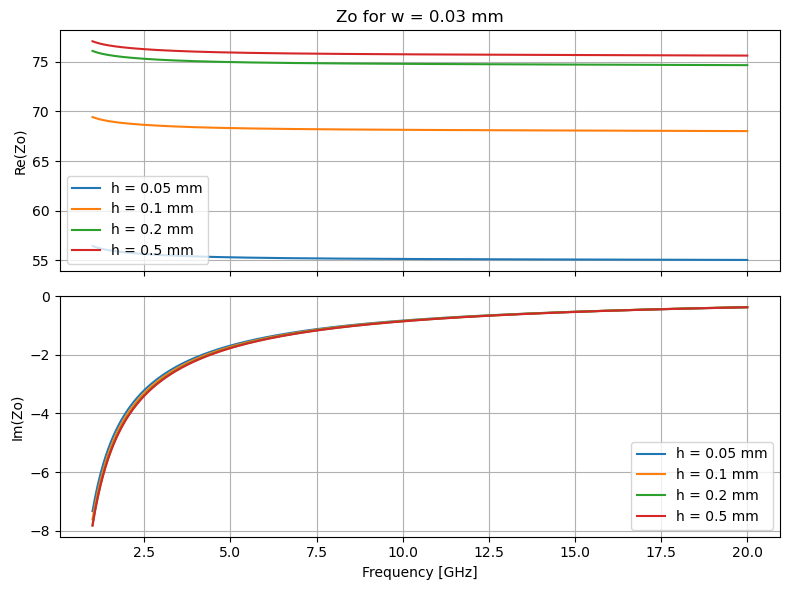

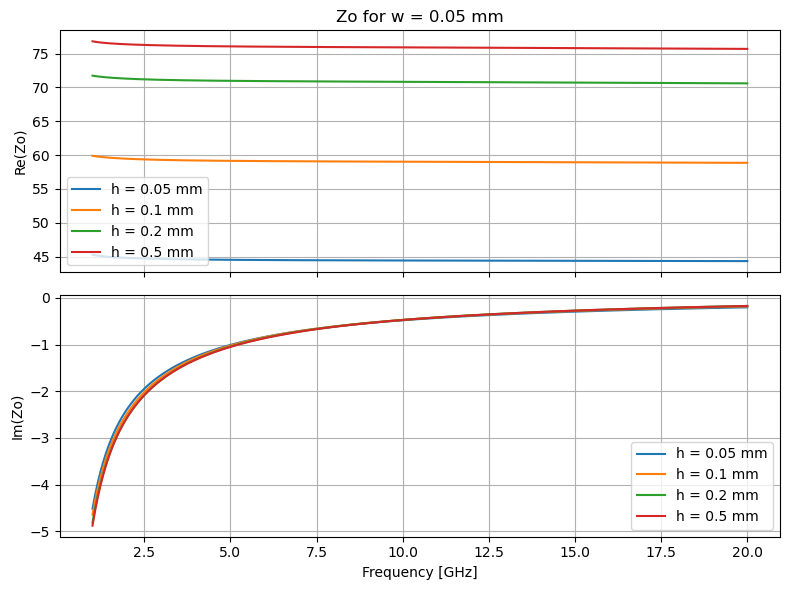

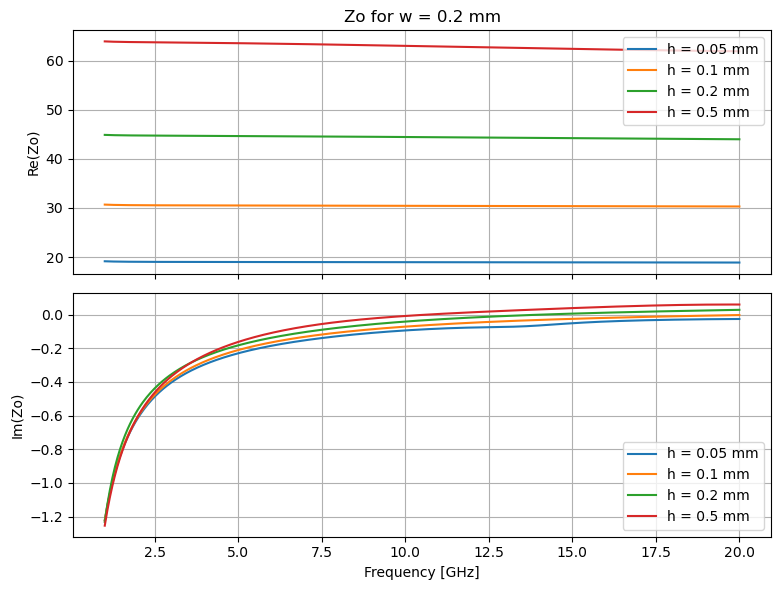

In [5]:
import matplotlib.pyplot as plt


class HFSSPlotter:
    def __init__(self, csv_file):
        self.csv_file = csv_file
        self.data = None

        self.col_h = "h [mm]"
        self.col_w = "w [mm]"
        self.col_freq = "Freq [GHz]"
        self.col_ReZo = "re(Zo(Port_In)) []"
        self.col_ImZo = "im(Zo(Port_In)) []"
        self.col_s11 = "dB(S(Port_In,Port_In)) []"
        self.col_s21 = "dB(S(Port_Out,Port_In)) []"

    def load_data(self):
        self.data = pd.read_csv(self.csv_file)

    def check_columns(self):
        required_columns = [
            self.col_h,
            self.col_w,
            self.col_freq,
            self.col_ReZo,
            self.col_ImZo,
            self.col_s11,
            self.col_s21,
        ]

        missing = [col for col in required_columns if col not in self.data.columns]
        if missing:
            raise ValueError(f"Missing columns: {missing}")

    def plot_for_each_w(self):
        unique_w_values = sorted(self.data[self.col_w].unique())

        for w_value in unique_w_values:
            df_w = self.data[self.data[self.col_w] == w_value].copy()

            fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

            for h_value in sorted(df_w[self.col_h].unique()):
                df_wh = df_w[df_w[self.col_h] == h_value].copy()
                df_wh = df_wh.sort_values(by=self.col_freq)

                axes[0].plot(
                    df_wh[self.col_freq],
                    df_wh[self.col_ReZo],
                    label=f"h = {h_value} mm"
                )

                axes[1].plot(
                    df_wh[self.col_freq],
                    df_wh[self.col_ImZo],
                    label=f"h = {h_value} mm"
                )

            axes[0].set_ylabel("Re(Zo)")
            axes[0].set_title(f"Zo for w = {w_value} mm")
            axes[0].grid(True)
            axes[0].legend()

            axes[1].set_xlabel("Frequency [GHz]")
            axes[1].set_ylabel("Im(Zo)")
            axes[1].grid(True)
            axes[1].legend()

            plt.tight_layout()
            plt.show()

    def run(self):
        self.load_data()
        self.check_columns()
        self.plot_for_each_w()


if __name__ == "__main__":
    csv_file = "Project3_param_sweep_ReZo_ImZo_S.csv"
    plotter = HFSSPlotter(csv_file)
    plotter.run()

### Zo at f_ext=9.4 GHz

In [13]:
import pandas as pd
import numpy as np


class HFSSImpedanceTable:
    def __init__(self, csv_file):
        self.csv_file = csv_file
        self.data = None

        self.col_h = "h [mm]"
        self.col_w = "w [mm]"
        self.col_freq = "Freq [GHz]"
        self.col_ReZo = "Re(Zo) [Ohm]"
        self.col_ImZo = "Im(Zo) [Ohm]"

    def load_data(self):
        self.data = pd.read_csv(self.csv_file)
        self.data = self.data.rename(columns={
            "re(Zo(Port_In)) []": "Re(Zo) [Ohm]",
            "im(Zo(Port_In)) []": "Im(Zo) [Ohm]",
        })
    def check_columns(self):
        required_columns = [
            self.col_h,
            self.col_w,
            self.col_freq,
            self.col_ReZo,
            self.col_ImZo,
        ]

        missing = [col for col in required_columns if col not in self.data.columns]
        if missing:
            raise ValueError(f"Missing columns: {missing}")

    def make_table_at_frequency(self, target_freq=9.4, tol=1e-2):
        # Keep only rows at the target frequency
        df = self.data[np.isclose(self.data[self.col_freq], target_freq, atol=tol)].copy()

        if df.empty:
            raise ValueError(f"No data found at {target_freq} GHz")

        # Compute magnitude of impedance
        df["|Z| [Ohm]"] = np.sqrt(df[self.col_ReZo]**2 + df[self.col_ImZo]**2)

        # Keep only useful columns
        df = df[
            [
                self.col_w,       # leftmost column
                self.col_h,
                self.col_ReZo,
                self.col_ImZo,
                "|Z| [Ohm]",
            ]
        ]

        # Sort rows by h first, then w
        df = df.sort_values(by=[self.col_w, self.col_h]).reset_index(drop=True)

        return df

    def run(self, target_freq=9.4):
        self.load_data()
        self.check_columns()
        table = self.make_table_at_frequency(target_freq)

        print(f"\nImpedance table at {target_freq} GHz:\n")
        print(table.to_string(index=False))

        return table


if __name__ == "__main__":
    csv_file = "Project3_param_sweep_ReZo_ImZo_S.csv"
    hfss_table = HFSSImpedanceTable(csv_file)
    table = hfss_table.run(9.4)

    # Optional: save the table to a new CSV file
    table.to_csv("impedance_table_9p4GHz.csv", index=False)


Impedance table at 9.4 GHz:

 w [mm]  h [mm]  Re(Zo) [Ohm]  Im(Zo) [Ohm]  |Z| [Ohm]
   0.03    0.05     55.138549     -0.888035  55.145700
   0.03    0.10     68.159152     -0.901286  68.165111
   0.03    0.20     74.811607     -0.913558  74.817184
   0.03    0.50     75.774369     -0.919037  75.779943
   0.05    0.05     44.422794     -0.515002  44.425779
   0.05    0.10     59.036219     -0.508674  59.038411
   0.05    0.20     70.853460     -0.510006  70.855296
   0.05    0.50     75.945557     -0.512652  75.947287
   0.20    0.05     18.954242     -0.102494  18.954519
   0.20    0.10     30.431306     -0.080529  30.431413
   0.20    0.20     44.475326     -0.050872  44.475355
   0.20    0.50     63.093487     -0.016792  63.093489


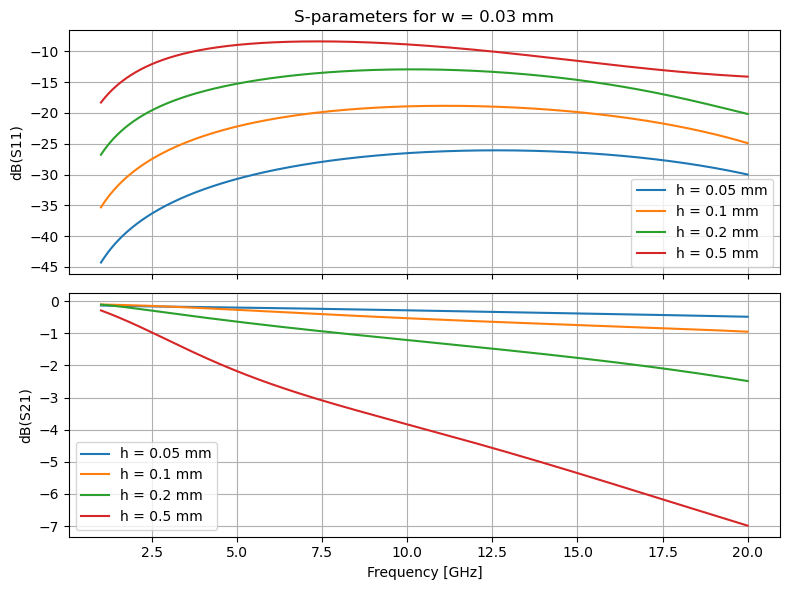

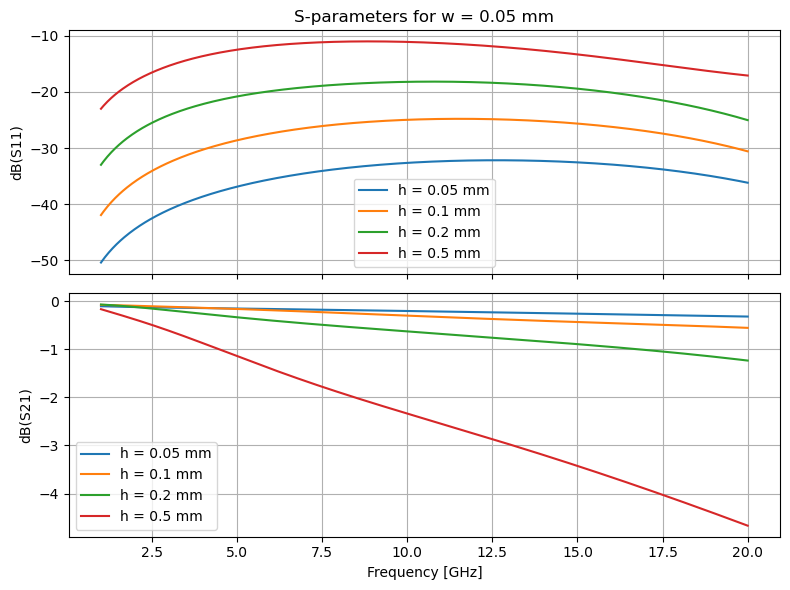

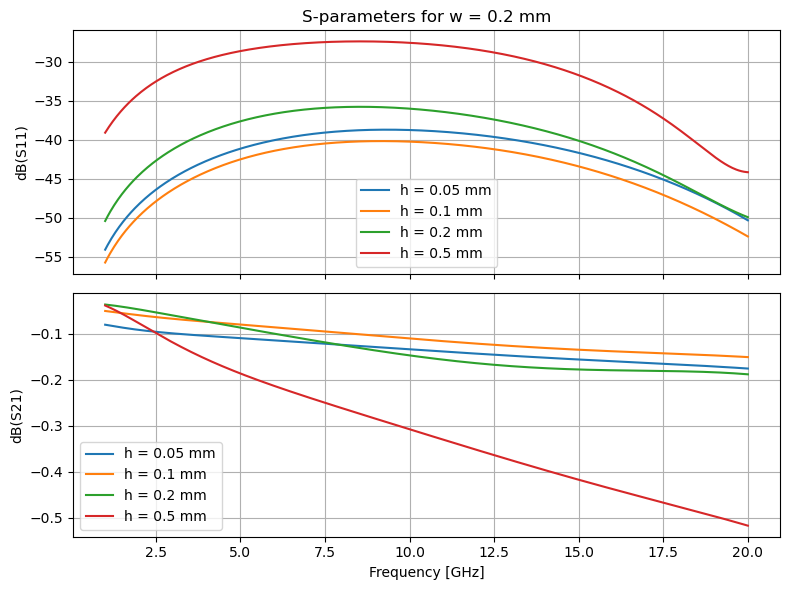

In [14]:
import matplotlib.pyplot as plt


class HFSSPlotter:
    def __init__(self, csv_file):
        self.csv_file = csv_file
        self.data = None

        self.col_h = "h [mm]"
        self.col_w = "w [mm]"
        self.col_freq = "Freq [GHz]"
        self.col_ReZo = "re(Zo(Port_In)) []"
        self.col_ImZo = "im(Zo(Port_In)) []"
        self.col_s11 = "dB(S(Port_In,Port_In)) []"
        self.col_s21 = "dB(S(Port_Out,Port_In)) []"

    def load_data(self):
        self.data = pd.read_csv(self.csv_file)

    def check_columns(self):
        required_columns = [
            self.col_h,
            self.col_w,
            self.col_freq,
            self.col_ReZo,
            self.col_ImZo,
            self.col_s11,
            self.col_s21,
        ]

        missing = [col for col in required_columns if col not in self.data.columns]
        if missing:
            raise ValueError(f"Missing columns: {missing}")

    def plot_for_each_w(self):
        unique_w_values = sorted(self.data[self.col_w].unique())

        for w_value in unique_w_values:
            df_w = self.data[self.data[self.col_w] == w_value].copy()

            fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

            for h_value in sorted(df_w[self.col_h].unique()):
                df_wh = df_w[df_w[self.col_h] == h_value].copy()
                df_wh = df_wh.sort_values(by=self.col_freq)

                axes[0].plot(
                    df_wh[self.col_freq],
                    df_wh[self.col_s11],
                    label=f"h = {h_value} mm"
                )

                axes[1].plot(
                    df_wh[self.col_freq],
                    df_wh[self.col_s21],
                    label=f"h = {h_value} mm"
                )

                axes[0].set_ylabel("dB(S11)")
                axes[0].set_title(f"S-parameters for w = {w_value} mm")
                axes[0].grid(True)
                axes[0].legend()

                axes[1].set_xlabel("Frequency [GHz]")
                axes[1].set_ylabel("dB(S21)")
                axes[1].grid(True)
                axes[1].legend()
                
            plt.tight_layout()
            plt.show()

    def run(self):
        self.load_data()
        self.check_columns()
        self.plot_for_each_w()


if __name__ == "__main__":
    csv_file = "Project3_param_sweep_ReZo_ImZo_S.csv"
    plotter = HFSSPlotter(csv_file)
    plotter.run()

Since the ports used for the simulations were wave ports, a change in the S11 parameters with dimensions was not expected. S11 has the same behaviour when plotted directly in HFSS. One possible explanation of this change in S11 is that the wave ports did not have the right dimensions. I will check this next.

## Ports field distribution
Here the ports field distribution is plotted for w_line=0.03 mm and the four values of h_subs considered in this study.

h_subs=0.05

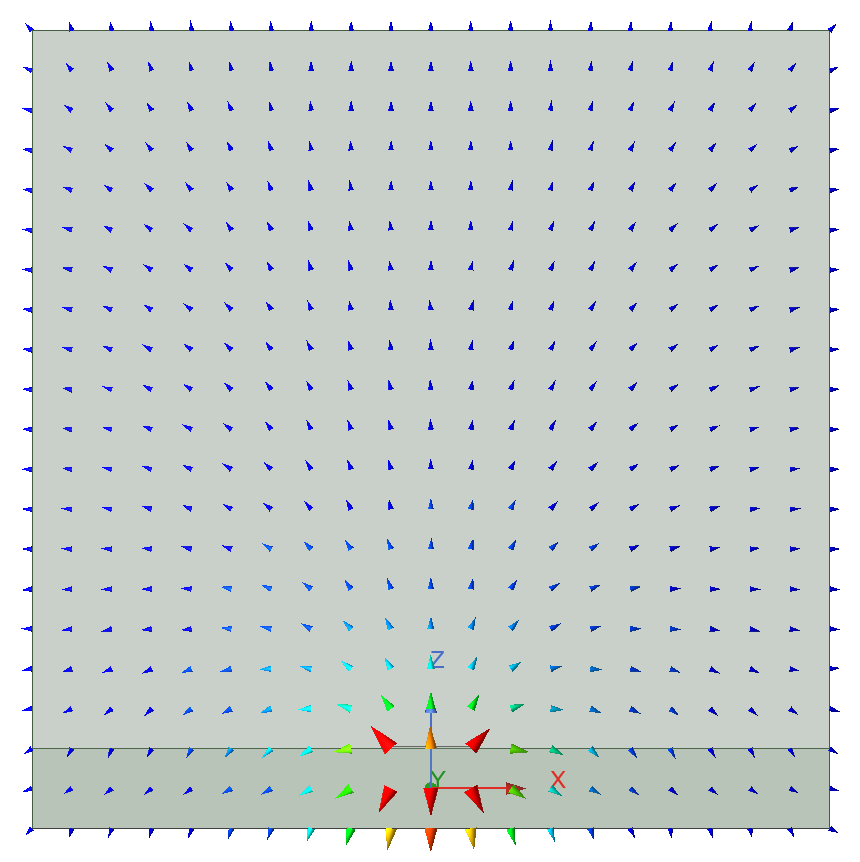

h_subs=0.10

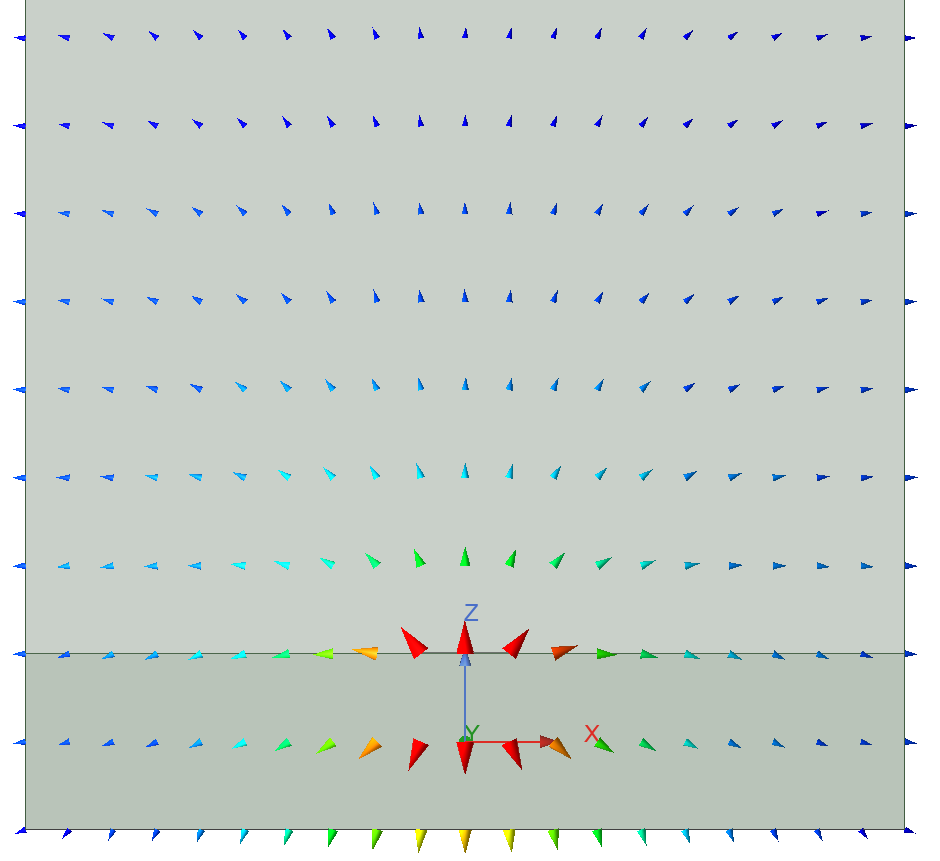

h_subs=0.20

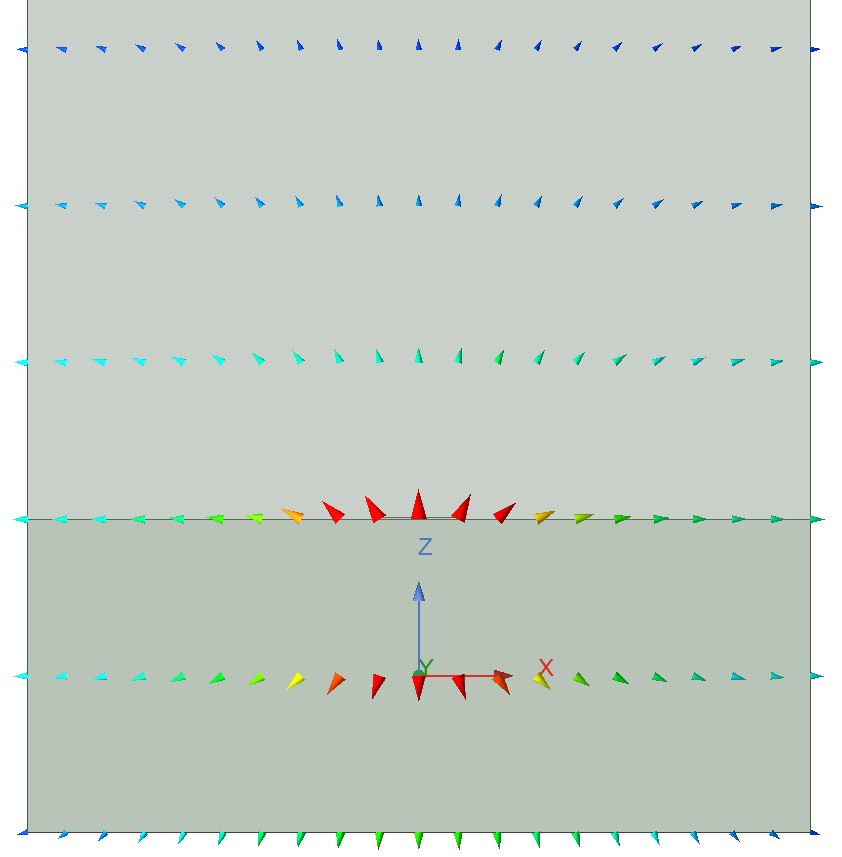

h_subs=0.50

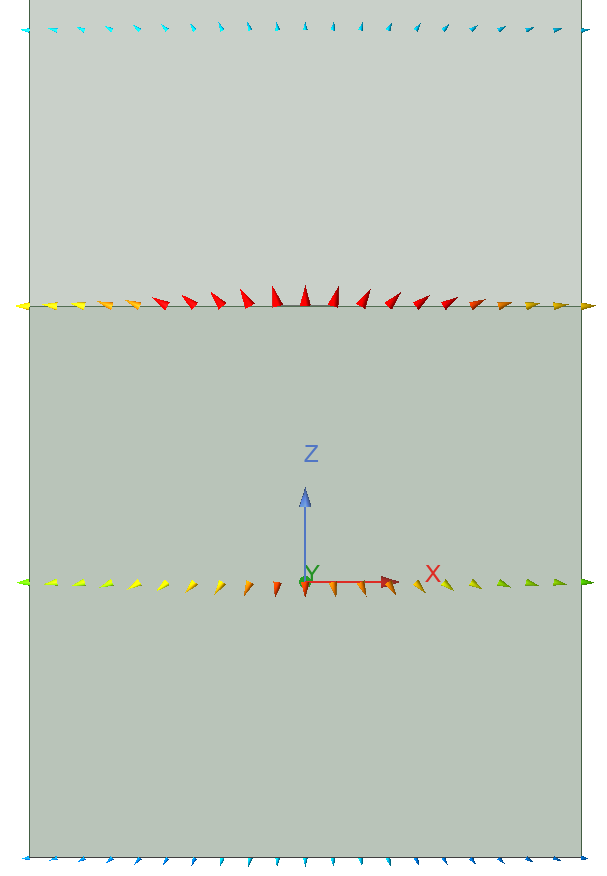

It is clearly observed that as h increases the field couples more and more to the sidewalls

## Increase of w_subs
w_subs is increased to 20*w, and the wave port width too

h_subs=0.05mm

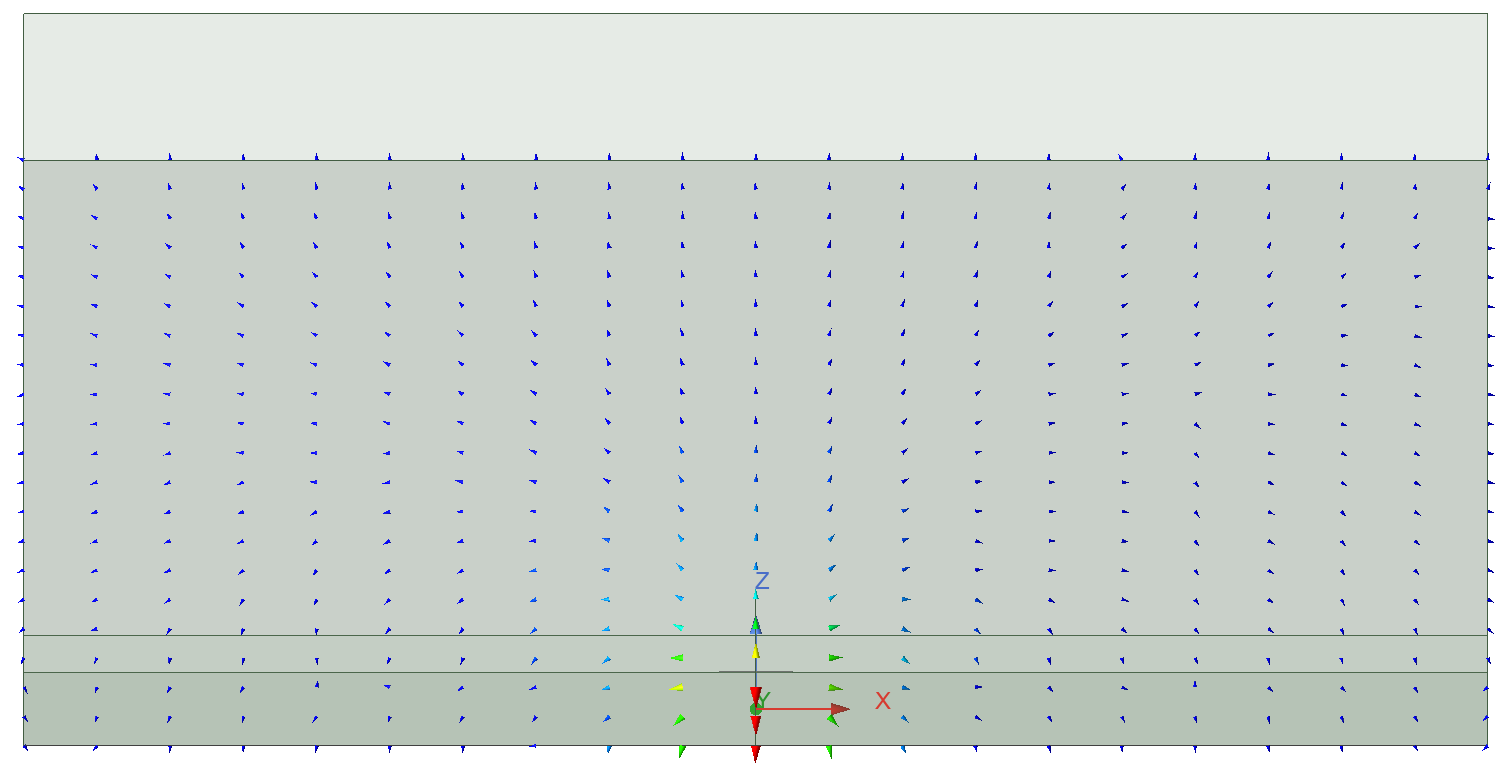

h_subs=0.1mm

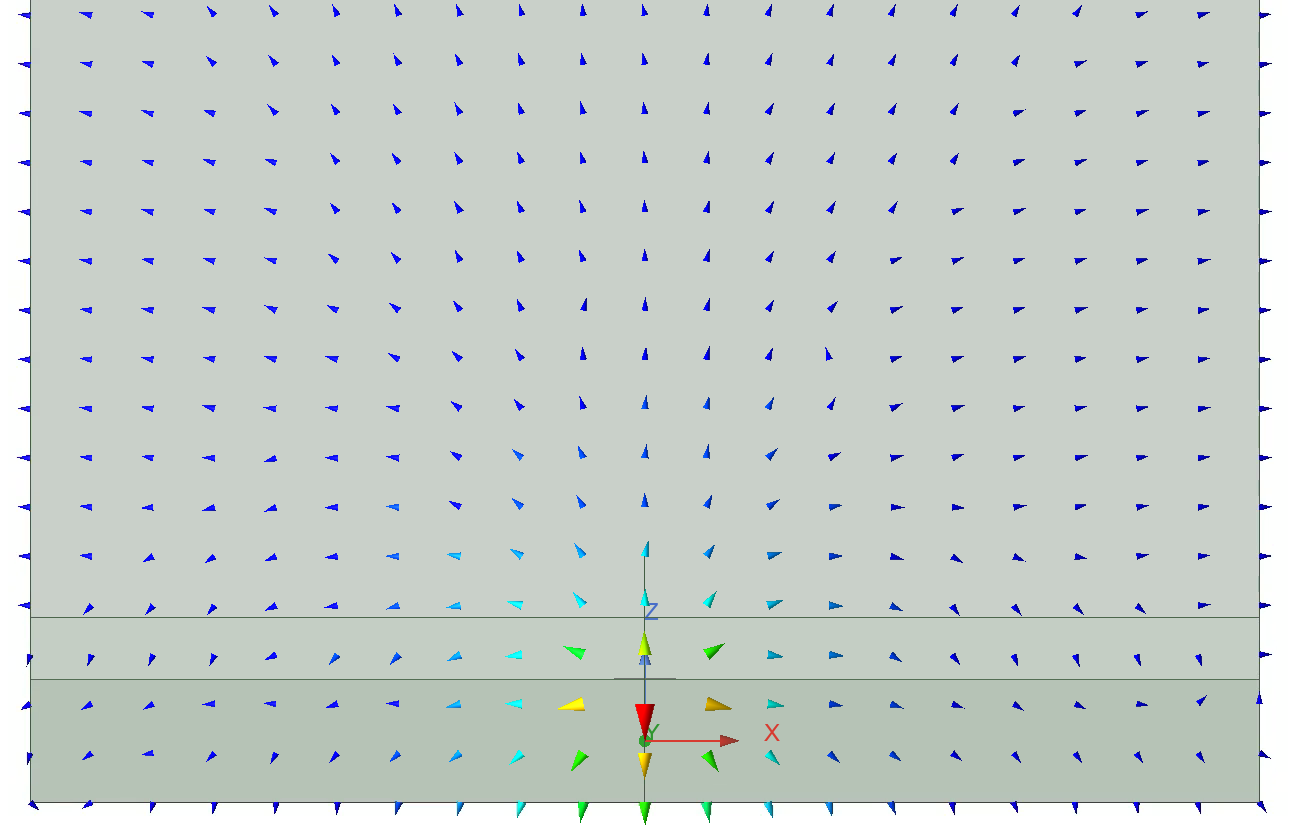

The port field was analysed also keeping the wave port width smaller than w_subs (a  half) and the results were the same regarding the field at the wave port boundary.

**Question:** the fact that at the sidewalls the field is perpendicular to the walls means that the wave port width should be increased ? Or if it is already a small field, it doesn't matter ?

Using w_subs=50*w the field at the sidewalls is not perpendicular anymore:

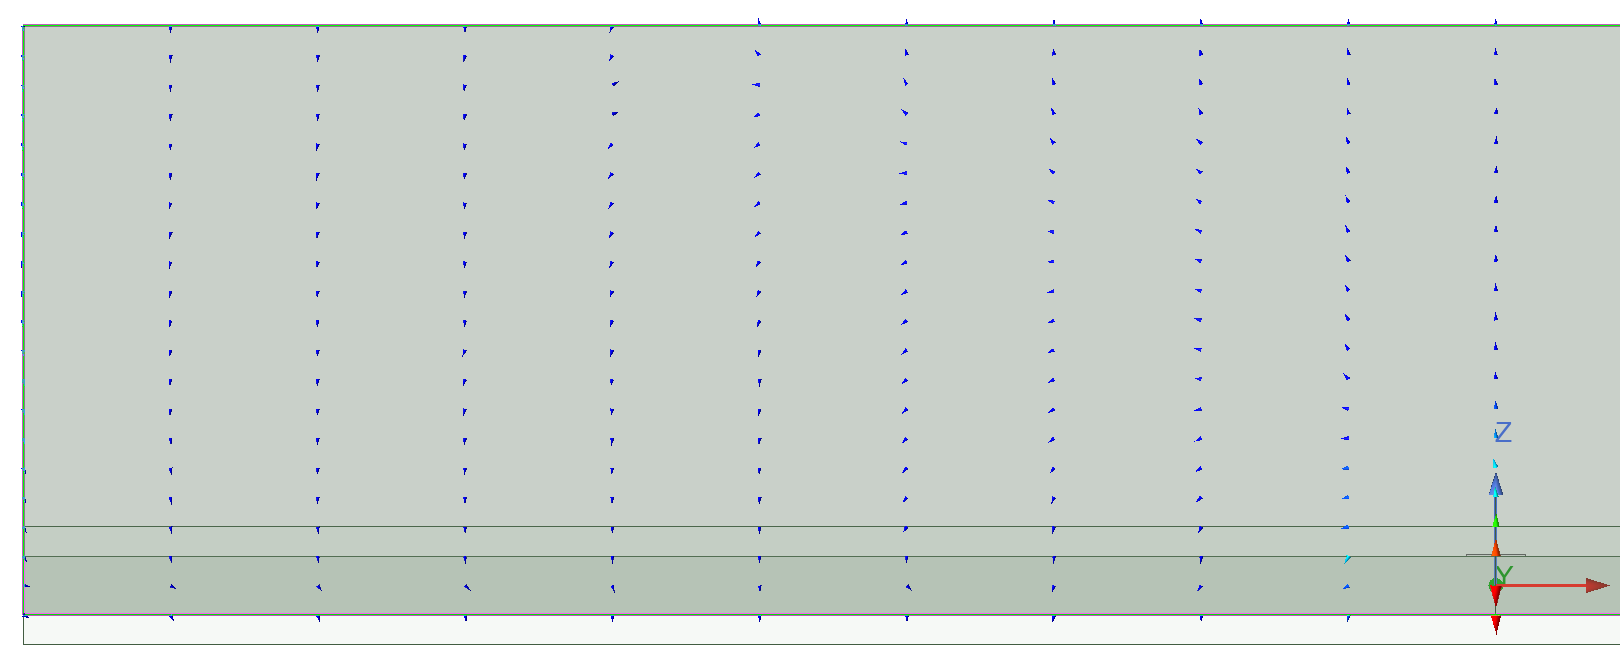

### Conclusions regarding the wave ports size
1. The larger h_subs is, the more w_subs has to be increased to avoid that the field couples to the sidewalls.
2. The height of the wave port should be reduced for large h, I did not show it here but in the highest part of the port there was coupling between the ports apparently.

### Next steps
1. Verify port fields for h=0.2,0.5 using port heigth of 4*h. Coupling to the upper wall?
2. Verify port fields for h=0.2,0.5 using w_subs=20*w. Coupling to the sidewalls?
3. For larger w, is it required a larger w_subs?
4. Re-simulate considering all this. S11 is still varying with dimensions?


In [16]:
import numpy as np
c=3e8
f=9.4e9
wlength=c/f
w, h, t_line, L = 0.05, 0.05, 0.001, 2
w_subs = 10*w
print(f'x: {-w_subs/2:.4f} - {w_subs/2:.4f}; step: {w_subs/100:.4f}')
print(f'y: {-L/2:.4f} - {L/2:.4f}; step: {L/100:.4f}')
print(f'z: {-h/2:.4f} - {3/4*h:.4f}; step: {h/100:.4f}')

x: -0.2500 - 0.2500; step: 0.0050
y: -1.0000 - 1.0000; step: 0.0200
z: -0.0250 - 0.0375; step: 0.0005
